# Adaptive Client-Specific DP for Federated IDS — calibrated version

This notebook does the following:

1. load the ECU-IoHT and WUSTL-EHMS tabular IDS datasets;
2. preprocess them for binary classification;
3. simulate heterogeneous federated clients with Dirichlet splitting;
4. run leakage audits and simple baselines before making DP claims;
5. compare centralized, FedAvg, fixed-noise LDP-FL, and smoothed adaptive-noise FL;
6. run fixed-noise privacy/utility sweeps;
7. run an adaptive-sigma calibration study on the strict no-ID WUSTL benchmark; and
8. report plots, tables, and client-level diagnostics.


## Part 1 — Imports, seed, device, and runtime knobs


In [90]:
import math
import random
import warnings
import json
import pickle
import hashlib
from dataclasses import dataclass, replace, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Any, Callable

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Prefer CUDA when available, then Apple Silicon MPS, then CPU.
# On your Mac, this should choose mps if your PyTorch build supports it.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

set_seed(42)
print("Using device:", DEVICE)

# Runtime controls.
# Keep USE_CACHE=True. First full run still trains, but repeat runs are much faster.
USE_CACHE = True
FORCE_RECOMPUTE = False
CACHE_VERSION = "v4_mps_calibrated_adaptive_sigma"
CACHE_DIR = Path(".adaptive_dp_cache")
RESULTS_DIR = Path("adaptive_dp_results")
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Reduce markdown/log bloat. Set True only when debugging round-by-round behavior.
ROUND_VERBOSE = False

# Main experiment toggles.
RUN_ORIGINAL_EXPLORATORY = True
RUN_STRICT_NO_ID = True
RUN_FIXED_SWEEPS = True
RUN_ADAPTIVE_CALIBRATION = True

# If you only want a quick smoke test while editing, set QUICK_DEV_RUN=True.
# The final reported numbers should use QUICK_DEV_RUN=False.
QUICK_DEV_RUN = False


Using device: mps


## Part 2 — Global config / experiment knobs


In [91]:
@dataclass
class FLConfig:
    # Paths
    ecu_path: str = "cleaned_ecu.parquet"
    wustl_path: str = "cleaned_wustl.parquet"

    # Reproducibility
    seed: int = 42

    # Data
    label_col: str = "label"
    test_size: float = 0.2
    val_size_within_train: float = 0.1

    # Client simulation
    n_clients: int = 8
    dirichlet_alpha: float = 0.3
    min_client_size: int = 64

    # Model / local training
    hidden_dim: int = 64
    local_epochs: int = 2
    batch_size: int = 128
    lr: float = 1e-3
    use_pos_weight: bool = False

    # Federated training
    rounds: int = 20
    clients_per_round: int = 4
    weighted_aggregation: bool = True
    early_stopping_patience: int | None = 5

    # DP strategy
    # fixed_noise, smoothed_sigma, adaptive_clip
    dp_strategy: str = "fixed_noise"

    # Fixed / adaptive sigma
    base_sigma: float = 0.02
    sigma_min: float = 0.005
    sigma_max: float = 1.00 # Testing a bigger range

    # Smoothed norm-based sigma rule
    sigma_smoothing: float = 0.8
    sigma_scale_beta: float = 0.15

    # Clipping
    clip_norm: float = 1.0
    clip_min: float = 0.1
    clip_max: float = 10.0

    # Adaptive clipping
    adaptive_clip_quantile: float = 0.5
    adaptive_clip_lr: float = 0.2

    # Threshold tuning
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.linspace(0.05, 0.95, 19), 2))

    # Verbosity
    verbose: bool = True


if QUICK_DEV_RUN:
    base_cfg = FLConfig(verbose=False, seed=42, rounds=5, clients_per_round=4, early_stopping_patience=3)
else:
    base_cfg = FLConfig(verbose=False, seed=42)

print(base_cfg)


FLConfig(ecu_path='cleaned_ecu.parquet', wustl_path='cleaned_wustl.parquet', seed=42, label_col='label', test_size=0.2, val_size_within_train=0.1, n_clients=8, dirichlet_alpha=0.3, min_client_size=64, hidden_dim=64, local_epochs=2, batch_size=128, lr=0.001, use_pos_weight=False, rounds=20, clients_per_round=4, weighted_aggregation=True, early_stopping_patience=5, dp_strategy='fixed_noise', base_sigma=0.02, sigma_min=0.005, sigma_max=1.0, sigma_smoothing=0.8, sigma_scale_beta=0.15, clip_norm=1.0, clip_min=0.1, clip_max=10.0, adaptive_clip_quantile=0.5, adaptive_clip_lr=0.2, threshold_grid=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95)), verbose=False)


## Part 3 — Caching helpers

These helpers keep repeat executions from retraining every model. If you change core logic and want fresh results, set `FORCE_RECOMPUTE = True` near the top or delete `.adaptive_dp_cache/`.


In [92]:
def _jsonable_cfg(cfg: FLConfig) -> dict:
    d = asdict(cfg)
    d["threshold_grid"] = list(cfg.threshold_grid)
    return d


def _stable_hash(obj: Any) -> str:
    payload = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.md5(payload).hexdigest()[:16]


def experiment_cache_path(bundle: Dict[str, Any], cfg: FLConfig, label: str = "") -> Path:
    key_obj = {
        "cache_version": CACHE_VERSION,
        "label": label,
        "dataset_name": bundle.get("dataset_name"),
        "x_train_shape": tuple(bundle["X_train"].shape),
        "x_val_shape": tuple(bundle["X_val"].shape),
        "x_test_shape": tuple(bundle["X_test"].shape),
        "y_train_pos": float(np.mean(bundle["y_train"])),
        "cfg": _jsonable_cfg(cfg),
    }
    return CACHE_DIR / f"experiment_{_stable_hash(key_obj)}.pkl"


def dataframe_cache_path(name: str, extra: dict | None = None) -> Path:
    key_obj = {
        "cache_version": CACHE_VERSION,
        "name": name,
        "extra": extra or {},
    }
    return CACHE_DIR / f"df_{_stable_hash(key_obj)}.pkl"


def load_or_compute_dataframe(name: str, compute_fn: Callable[[], pd.DataFrame], extra: dict | None = None) -> pd.DataFrame:
    path = dataframe_cache_path(name, extra=extra)
    if USE_CACHE and not FORCE_RECOMPUTE and path.exists():
        print(f"Loaded cached dataframe: {name}")
        return pd.read_pickle(path)
    df = compute_fn()
    if USE_CACHE:
        df.to_pickle(path)
    return df


def run_experiment_cached(bundle: Dict[str, Any], cfg: FLConfig, label: str = "") -> Dict[str, Any]:
    path = experiment_cache_path(bundle, cfg, label=label)
    if USE_CACHE and not FORCE_RECOMPUTE and path.exists():
        print(f"Loaded cached experiment: {bundle['dataset_name']} / {label or cfg.dp_strategy}")
        with open(path, "rb") as f:
            return pickle.load(f)

    print(f"Running experiment: {bundle['dataset_name']} / {label or cfg.dp_strategy}")
    result = run_experiment(bundle, cfg)

    if USE_CACHE:
        with open(path, "wb") as f:
            pickle.dump(result, f)
    return result


## Part 4 — Data loading + basic sanity checks


In [93]:
def load_datasets(cfg: FLConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    ecu_df = pd.read_parquet(cfg.ecu_path)
    wustl_df = pd.read_parquet(cfg.wustl_path)
    return ecu_df, wustl_df


def dataset_sanity_check(df: pd.DataFrame, label_col: str, name: str) -> pd.DataFrame:
    print(f"{name} sanity check")
    print("Label counts:")
    print(df[label_col].value_counts().sort_index())
    print("Top missing columns:")
    print(df.isna().sum().sort_values(ascending=False).head(10))

    out = pd.DataFrame([
        {
            "n_rows": df.shape[0],
            "n_cols": df.shape[1],
            "n_missing_total": int(df.isna().sum().sum()),
            "positive_rate": float(df[label_col].mean()),
        }
    ])
    return out


ecu_df, wustl_df = load_datasets(base_cfg)
print("ECU shape:", ecu_df.shape)
print("WUSTL shape:", wustl_df.shape)

display(dataset_sanity_check(ecu_df, "label", "ECU"))
print()
display(dataset_sanity_check(wustl_df, "label", "WUSTL"))


ECU shape: (111207, 6)
WUSTL shape: (16318, 43)
ECU sanity check
Label counts:
label
0    23453
1    87754
Name: count, dtype: int64
Top missing columns:
Time           0
Source         0
Destination    0
Protocol       0
Length         0
label          0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,111207,6,0,0.789105



WUSTL sanity check
Label counts:
label
0    14272
1     2046
Name: count, dtype: int64
Top missing columns:
Dir         0
SrcMac      0
TotPkts     0
TotBytes    0
Load        0
Loss        0
pLoss       0
pSrcLoss    0
pDstLoss    0
Rate        0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,16318,43,0,0.125383


## Part 5 — Preprocessing utilities


In [94]:
def load_polars_or_pandas(df_like) -> pd.DataFrame:
    if isinstance(df_like, pl.DataFrame):
        return df_like.to_pandas()
    if isinstance(df_like, pd.DataFrame):
        return df_like.copy()
    raise TypeError("Expected a polars or pandas DataFrame.")


def prepare_binary_tabular_data(
    df_like,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    df = load_polars_or_pandas(df_like)
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col]).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_df,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=random_state,
    )

    X_train = pd.get_dummies(X_train, dummy_na=True)
    X_val = pd.get_dummies(X_val, dummy_na=True)
    X_test = pd.get_dummies(X_test, dummy_na=True)

    X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    feature_names = list(X_train.columns)

    scaler = StandardScaler()
    X_train_np = scaler.fit_transform(X_train.astype(np.float32))
    X_val_np = scaler.transform(X_val.astype(np.float32))
    X_test_np = scaler.transform(X_test.astype(np.float32))

    return (
        X_train_np.astype(np.float32),
        X_val_np.astype(np.float32),
        X_test_np.astype(np.float32),
        y_train.astype(np.float32),
        y_val.astype(np.float32),
        y_test.astype(np.float32),
        feature_names,
    )


def build_dataset_bundle(raw_df_like, cfg: FLConfig, dataset_name: str) -> Dict[str, Any]:
    X_train, X_val, X_test, y_train, y_val, y_test, feature_names = prepare_binary_tabular_data(
        raw_df_like,
        label_col=cfg.label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        random_state=cfg.seed,
    )
    return {
        "dataset_name": dataset_name,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": feature_names,
    }


## Part 6 — Client simulation utilities


In [95]:
def dirichlet_split_indices(
    y: np.ndarray,
    n_clients: int,
    alpha: float = 0.3,
    min_size: int = 64,
    seed: int = 42,
) -> List[np.ndarray]:
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(n_clients)]

        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)
            proportions = rng.dirichlet(np.repeat(alpha, n_clients))
            cuts = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            splits = np.split(cls_idx, cuts)
            for client_id, chunk in enumerate(splits):
                client_indices[client_id].extend(chunk.tolist())

        client_indices = [np.array(idx, dtype=int) for idx in client_indices]
        if min(len(idx) for idx in client_indices) >= min_size:
            return client_indices


def summarize_clients(y: np.ndarray, client_indices: List[np.ndarray]) -> pd.DataFrame:
    rows = []
    global_pos = float(np.mean(y))
    for cid, idx in enumerate(client_indices):
        yc = y[idx]
        pos_rate = float(np.mean(yc)) if len(yc) > 0 else 0.0
        rows.append({
            "client_id": cid,
            "n_samples": len(idx),
            "pos_rate": pos_rate,
            "imbalance_vs_global": abs(pos_rate - global_pos),
        })
    return pd.DataFrame(rows)


def attach_clients_to_bundle(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    client_indices = dirichlet_split_indices(
        y=bundle["y_train"].astype(int),
        n_clients=cfg.n_clients,
        alpha=cfg.dirichlet_alpha,
        min_size=cfg.min_client_size,
        seed=cfg.seed,
    )
    client_summary = summarize_clients(bundle["y_train"], client_indices)
    out = dict(bundle)
    out["client_indices"] = client_indices
    out["client_summary"] = client_summary
    return out


## Part 7 — Model + state helpers


In [96]:
class BinaryMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def get_model_state(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().clone().cpu() for k, v in model.state_dict().items()}


def set_model_state(model: nn.Module, state: Dict[str, torch.Tensor]) -> None:
    model.load_state_dict(state, strict=True)


def state_sub(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] - b[k] for k in a.keys()}


def state_add(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] + b[k] for k in a.keys()}


def state_mul(a: Dict[str, torch.Tensor], scalar: float) -> Dict[str, torch.Tensor]:
    return {k: a[k] * scalar for k in a.keys()}


def state_l2_norm(state: Dict[str, torch.Tensor]) -> float:
    total = 0.0
    for v in state.values():
        total += float(torch.sum(v.float() ** 2))
    return math.sqrt(total)


def clip_state_by_l2(state: Dict[str, torch.Tensor], clip_norm: float) -> Tuple[Dict[str, torch.Tensor], float]:
    norm = state_l2_norm(state)
    if norm <= clip_norm or norm == 0.0:
        return {k: v.clone() for k, v in state.items()}, norm
    scale = clip_norm / norm
    return {k: v * scale for k, v in state.items()}, norm


def add_gaussian_noise_to_state(
    state: Dict[str, torch.Tensor],
    sigma: float,
    clip_norm: float,
    device: torch.device = torch.device("cpu"),
) -> Dict[str, torch.Tensor]:
    """
    Add Gaussian noise to the clipped client update.

    Noise is generated on CPU because client states are stored on CPU before aggregation.
    MPS/CUDA are still used for model training and inference.
    """
    noisy = {}
    std = sigma * clip_norm
    for k, v in state.items():
        noise = torch.normal(mean=0.0, std=std, size=v.shape)
        noisy[k] = v + noise
    return noisy


## Part 8 — Local training + DP helpers


In [97]:
def make_client_loader(
    X: np.ndarray,
    y: np.ndarray,
    indices: np.ndarray,
    batch_size: int,
    shuffle: bool = True,
) -> DataLoader:
    Xc = torch.tensor(X[indices], dtype=torch.float32)
    yc = torch.tensor(y[indices], dtype=torch.float32)
    ds = TensorDataset(Xc, yc)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def local_train(
    global_state: Dict[str, torch.Tensor],
    X_train: np.ndarray,
    y_train: np.ndarray,
    client_idx: np.ndarray,
    cfg: FLConfig,
    in_dim: int,
) -> Dict[str, torch.Tensor]:
    model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, global_state)
    model.train()

    loader = make_client_loader(X_train, y_train, client_idx, cfg.batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    if cfg.use_pos_weight:
        yc = y_train[client_idx]
        pos = max(float(np.sum(yc == 1)), 1.0)
        neg = max(float(np.sum(yc == 0)), 1.0)
        pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    for _ in range(cfg.local_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    local_state = get_model_state(model)
    delta = state_sub(local_state, global_state)
    return delta


def compute_smoothed_sigma(
    raw_delta_norm: float,
    previous_smoothed_norm: float,
    clip_norm: float,
    cfg: FLConfig,
) -> Tuple[float, float, float]:
    if previous_smoothed_norm <= 0:
        smoothed_norm = raw_delta_norm
    else:
        smoothed_norm = cfg.sigma_smoothing * previous_smoothed_norm + (1.0 - cfg.sigma_smoothing) * raw_delta_norm

    norm_ratio = smoothed_norm / max(clip_norm, 1e-12)
    raw_sigma = cfg.base_sigma * (1.0 + cfg.sigma_scale_beta * np.log1p(norm_ratio))
    clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
    return float(raw_sigma), float(clipped_sigma), float(smoothed_norm)


## Part 9 — Evaluation + federated training loop


In [98]:
def sigmoid(logits):
    """
    Numerically stable sigmoid.
    """
    logits_arr = np.asarray(logits, dtype=np.float64)
    probs = np.empty_like(logits_arr, dtype=np.float64)

    positive = logits_arr >= 0
    negative = ~positive

    probs[positive] = 1.0 / (1.0 + np.exp(-logits_arr[positive]))

    exp_logits = np.exp(logits_arr[negative])
    probs[negative] = exp_logits / (1.0 + exp_logits)

    if np.isscalar(logits):
        return float(probs)

    return probs


def predict_proba_from_state(state: Dict[str, torch.Tensor], X: np.ndarray, cfg: FLConfig) -> np.ndarray:
    model = BinaryMLP(in_dim=X.shape[1], hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, state)
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(xb).cpu().numpy()
    return sigmoid(logits)


def find_best_threshold(y_true: np.ndarray, probs: np.ndarray, grid: Tuple[float, ...]) -> Tuple[float, Dict[str, float]]:
    """
    Choose the classification threshold using validation F1.

    This combines the fixed grid with probability-derived candidate thresholds.
    That prevents cases where AUC/PR-AUC are strong but F1 is bad only because
    the coarse grid missed the useful cutoff.
    """
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)

    finite_probs = probs[np.isfinite(probs)]
    if len(finite_probs) == 0:
        raise ValueError("No finite probabilities available for threshold tuning.")

    candidates = set(float(t) for t in grid)

    quantiles = np.linspace(0.0, 1.0, 501)
    prob_candidates = np.quantile(finite_probs, quantiles)
    candidates.update(float(t) for t in prob_candidates)

    eps = 1e-12
    candidates.add(float(np.min(finite_probs) - eps))
    candidates.add(float(np.max(finite_probs) + eps))

    candidates = sorted(candidates)

    best_threshold = 0.5
    best_f1 = -1.0
    best_metrics = None

    for t in candidates:
        preds = (probs >= t).astype(int)
        current_f1 = f1_score(y_true, preds, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(t)
            best_metrics = {
                "val_accuracy": accuracy_score(y_true, preds),
                "val_precision": precision_score(y_true, preds, zero_division=0),
                "val_recall": recall_score(y_true, preds, zero_division=0),
                "val_f1": current_f1,
            }

    return best_threshold, best_metrics


def compute_binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> Dict[str, float]:
    preds = (probs >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc": np.nan,
        "pr_auc": np.nan,
    }
    try:
        metrics["auc"] = roc_auc_score(y_true, probs)
    except ValueError:
        pass
    try:
        metrics["pr_auc"] = average_precision_score(y_true, probs)
    except ValueError:
        pass
    return metrics


def federated_train(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    set_seed(cfg.seed)  # fairness: reset seed for each run

    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]
    y_train = bundle["y_train"]
    y_val = bundle["y_val"]
    y_test = bundle["y_test"]
    client_indices = bundle["client_indices"]

    in_dim = X_train.shape[1]
    global_model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    global_state = get_model_state(global_model)

    global_pos_rate = float(np.mean(y_train))
    client_summary = bundle["client_summary"]
    mean_client_n = float(client_summary["n_samples"].mean())

    history_rows = []
    client_log_rows = []

    best_val_f1 = -np.inf
    best_round = None
    best_state = {k: v.clone() for k, v in global_state.items()}
    no_improve = 0

    current_clip_norm = float(cfg.clip_norm)
    smoothed_norms = {cid: 0.0 for cid in range(len(client_indices))}

    for rnd in range(1, cfg.rounds + 1):
        chosen = np.random.choice(
            len(client_indices),
            size=min(cfg.clients_per_round, len(client_indices)),
            replace=False,
        )

        client_updates = []
        client_weights = []
        round_raw_norms = []

        for cid in chosen:
            idx = client_indices[cid]
            client_n = len(idx)
            client_pos_rate = float(np.mean(y_train[idx]))
            imbalance_term = abs(client_pos_rate - global_pos_rate)
            size_term = math.sqrt(max(mean_client_n, 1.0) / max(client_n, 1.0))

            raw_delta = local_train(
                global_state=global_state,
                X_train=X_train,
                y_train=y_train,
                client_idx=idx,
                cfg=cfg,
                in_dim=in_dim,
            )
            raw_delta_norm = state_l2_norm(raw_delta)
            round_raw_norms.append(raw_delta_norm)

            if cfg.dp_strategy == "fixed_noise":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]
            elif cfg.dp_strategy == "smoothed_sigma":
                raw_sigma, clipped_sigma, smoothed_norm = compute_smoothed_sigma(
                    raw_delta_norm=raw_delta_norm,
                    previous_smoothed_norm=smoothed_norms[cid],
                    clip_norm=current_clip_norm,
                    cfg=cfg,
                )
                smoothed_norms[cid] = smoothed_norm
            elif cfg.dp_strategy == "adaptive_clip":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]
            else:
                raise ValueError("Unknown dp_strategy")

            clipped_delta, clipped_delta_norm = clip_state_by_l2(raw_delta, current_clip_norm)
            noisy_delta = add_gaussian_noise_to_state(
                state=clipped_delta,
                sigma=clipped_sigma,
                clip_norm=current_clip_norm,
                device=DEVICE,
            )

            client_updates.append(noisy_delta)
            client_weights.append(client_n if cfg.weighted_aggregation else 1.0)

            client_log_rows.append({
                "round": rnd,
                "client_id": int(cid),
                "dp_strategy": cfg.dp_strategy,
                "client_n": int(client_n),
                "client_pos_rate": float(client_pos_rate),
                "imbalance_term": float(imbalance_term),
                "size_term": float(size_term),
                "clip_norm_used": float(current_clip_norm),
                "raw_delta_norm": float(raw_delta_norm),
                "clipped_delta_norm": float(clipped_delta_norm),
                "norm_ratio": float(raw_delta_norm / max(current_clip_norm, 1e-12)),
                "smoothed_norm": float(smoothed_norm),
                "raw_sigma": float(raw_sigma),
                "sigma": float(clipped_sigma),
                "sigma_saturated": bool(abs(clipped_sigma - cfg.sigma_max) < 1e-12),
            })

        total_weight = float(np.sum(client_weights))
        agg_delta = None
        for upd, w in zip(client_updates, client_weights):
            scaled = state_mul(upd, float(w) / total_weight)
            agg_delta = scaled if agg_delta is None else state_add(agg_delta, scaled)
        global_state = state_add(global_state, agg_delta)

        next_clip_norm = current_clip_norm
        if cfg.dp_strategy == "adaptive_clip" and len(round_raw_norms) > 0:
            target_clip = float(np.quantile(round_raw_norms, cfg.adaptive_clip_quantile))
            next_clip_norm = (1.0 - cfg.adaptive_clip_lr) * current_clip_norm + cfg.adaptive_clip_lr * max(target_clip, 1e-8)
            next_clip_norm = float(np.clip(next_clip_norm, cfg.clip_min, cfg.clip_max))

        val_probs = predict_proba_from_state(global_state, X_val, cfg)
        best_threshold, val_summary = find_best_threshold(y_val, val_probs, cfg.threshold_grid)
        test_probs = predict_proba_from_state(global_state, X_test, cfg)

        test_metrics = compute_binary_metrics(y_test, test_probs, best_threshold)
        row = {
            "round": rnd,
            "dp_strategy": cfg.dp_strategy,
            "threshold": float(best_threshold),
            "clip_norm_used": float(current_clip_norm),
            "clip_norm_next": float(next_clip_norm),
            **val_summary,
            **test_metrics,
        }
        history_rows.append(row)

        if cfg.verbose:
            print(
                f"[Round {rnd:02d}] "
                f"acc={row['accuracy']:.4f} "
                f"f1={row['f1']:.4f} "
                f"auc={row['auc']:.4f} "
                f"pr_auc={row['pr_auc']:.4f} "
                f"thr={row['threshold']:.3g} "
                f"clip={row['clip_norm_used']:.3f}"
            )

        if row["val_f1"] > best_val_f1 + 1e-8:
            best_val_f1 = row["val_f1"]
            best_round = rnd
            best_state = {k: v.clone() for k, v in global_state.items()}
            no_improve = 0
        else:
            no_improve += 1

        current_clip_norm = next_clip_norm

        if cfg.early_stopping_patience is not None and no_improve >= cfg.early_stopping_patience:
            if cfg.verbose:
                print(f"Early stopping at round {rnd} (best val_f1 at round {best_round}).")
            break

    history_df = pd.DataFrame(history_rows)
    client_log_df = pd.DataFrame(client_log_rows)

    if best_round is None:
        best_round = int(history_df.iloc[history_df["val_f1"].idxmax()]["round"])
    best_row = history_df.loc[history_df["round"] == best_round].iloc[0].to_dict()

    summary = {
        "dataset": bundle["dataset_name"],
        "dp_strategy": cfg.dp_strategy,
        "best_round": int(best_round),
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "auc": float(best_row["auc"]),
        "pr_auc": float(best_row["pr_auc"]),
        "threshold": float(best_row["threshold"]),
        "val_f1": float(best_row["val_f1"]),
    }

    return {
        "best_state": best_state,
        "history": history_df,
        "client_log": client_log_df,
        "summary": summary,
    }


## Part 10 — Experiment wrapper and original bundles


In [99]:
def prepare_experiment_bundle(raw_df_like, cfg: FLConfig, dataset_name: str) -> Dict[str, Any]:
    bundle = build_dataset_bundle(raw_df_like, cfg, dataset_name)
    bundle = attach_clients_to_bundle(bundle, cfg)

    print(f"[{dataset_name}]")
    print(
        "Shapes:",
        {
            "train": bundle["X_train"].shape,
            "val": bundle["X_val"].shape,
            "test": bundle["X_test"].shape,
        },
    )
    display(bundle["client_summary"].describe(include="all"))
    return bundle


def run_experiment(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    result = federated_train(bundle, cfg)
    result["client_summary"] = bundle["client_summary"].copy()
    result["feature_count"] = bundle["X_train"].shape[1]
    return result


ecu_bundle = prepare_experiment_bundle(ecu_df, base_cfg, dataset_name="ECU")
wustl_bundle = prepare_experiment_bundle(wustl_df, base_cfg, dataset_name="WUSTL")


[ECU]
Shapes: {'train': (80068, 156), 'val': (8897, 156), 'test': (22242, 156)}


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.00000,8.000000,8.000000
mean,3.50000,10008.50000,0.704410,0.292696
std,2.44949,18944.37241,0.399846,0.264887
min,0.00000,314.00000,0.030240,0.079153
25%,1.75000,810.75000,0.561855,0.142164
50%,3.50000,2433.50000,0.924266,0.176760
75%,5.25000,7032.75000,0.956758,0.324008
max,7.00000,55781.00000,0.997268,0.758864


[WUSTL]
Shapes: {'train': (11748, 11801), 'val': (1306, 11801), 'test': (3264, 11801)}


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,1468.500000,0.314576,0.308624
std,2.44949,2049.721654,0.398488,0.301403
min,0.00000,151.000000,0.000000,0.087215
25%,1.75000,339.500000,0.003039,0.117405
50%,3.50000,393.000000,0.116176,0.125383
75%,5.25000,2008.500000,0.571047,0.445664
max,7.00000,6169.000000,1.000000,0.874617


## Part 11 — Sanity checks, leakage audits, and baselines

This section runs before the main DP comparison so the later results have context. To keep markdown exports readable, the notebook displays only the top rows of the leakage audit and saves the full audit tables to CSV.


In [100]:
def make_raw_split_indices(
    df: pd.DataFrame,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    seed: int = 42,
):
    y = df[label_col].astype(int).to_numpy()
    all_idx = np.arange(len(df))

    train_full_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=y,
        random_state=seed,
    )

    y_train_full = y[train_full_idx]

    train_idx, val_idx = train_test_split(
        train_full_idx,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=seed,
    )

    return train_idx, val_idx, test_idx


def single_column_lookup_baseline(
    df: pd.DataFrame,
    column: str,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    label_col: str = "label",
) -> dict:
    train = df.iloc[train_idx][[column, label_col]].copy()
    test = df.iloc[test_idx][[column, label_col]].copy()

    train[column] = train[column].astype("string").fillna("<NA>")
    test[column] = test[column].astype("string").fillna("<NA>")

    global_majority = int(train[label_col].mean() >= 0.5)

    label_rate_by_value = train.groupby(column)[label_col].mean()
    lookup = (label_rate_by_value >= 0.5).astype(int).to_dict()

    train_values = set(lookup.keys())
    seen_rate = float(test[column].isin(train_values).mean())

    preds = test[column].map(lookup).fillna(global_majority).astype(int).to_numpy()
    y_true = test[label_col].astype(int).to_numpy()

    return {
        "column": column,
        "dtype": str(df[column].dtype),
        "n_unique": int(df[column].nunique(dropna=False)),
        "unique_ratio": float(df[column].nunique(dropna=False) / len(df)),
        "test_seen_value_rate": seen_rate,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


def audit_dataset_leakage(
    df: pd.DataFrame,
    dataset_name: str,
    cfg: FLConfig,
    label_col: str = "label",
) -> pd.DataFrame:
    train_idx, val_idx, test_idx = make_raw_split_indices(
        df=df,
        label_col=label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        seed=cfg.seed,
    )

    rows = []
    for column in df.columns:
        if column == label_col:
            continue

        try:
            rows.append(
                single_column_lookup_baseline(
                    df=df,
                    column=column,
                    train_idx=train_idx,
                    test_idx=test_idx,
                    label_col=label_col,
                )
            )
        except Exception as e:
            rows.append({
                "column": column,
                "error": str(e),
            })

    audit = pd.DataFrame(rows)
    audit.insert(0, "dataset", dataset_name)

    id_words = ["mac", "addr", "ip", "source", "destination", "src", "dst", "sport", "dport", "time"]
    audit["id_like_name"] = audit["column"].str.lower().apply(
        lambda c: any(w in c for w in id_words)
    )

    return audit.sort_values(["f1", "accuracy"], ascending=False)


ecu_leakage_audit = load_or_compute_dataframe(
    "ecu_leakage_audit",
    lambda: audit_dataset_leakage(ecu_df, "ECU", base_cfg, label_col="label"),
    extra={"seed": base_cfg.seed},
)
wustl_leakage_audit = load_or_compute_dataframe(
    "wustl_leakage_audit",
    lambda: audit_dataset_leakage(wustl_df, "WUSTL", base_cfg, label_col="label"),
    extra={"seed": base_cfg.seed},
)

ecu_leakage_audit.to_csv(RESULTS_DIR / "ecu_single_column_leakage_audit.csv", index=False)
wustl_leakage_audit.to_csv(RESULTS_DIR / "wustl_single_column_leakage_audit.csv", index=False)

print("ECU single-column leakage audit — top rows:")
display(ecu_leakage_audit.head(10))

print("WUSTL single-column leakage audit — top rows:")
display(wustl_leakage_audit.head(15))

print("Saved full leakage audits to:")
print(RESULTS_DIR / "ecu_single_column_leakage_audit.csv")
print(RESULTS_DIR / "wustl_single_column_leakage_audit.csv")


ECU single-column leakage audit — top rows:


,dataset,column,dtype,n_unique,unique_ratio,test_seen_value_rate,accuracy,precision,recall,f1,id_like_name
4,ECU,Length,int32,794,0.007140,0.995594,0.976666,0.978212,0.992536,0.985322,False
1,ECU,Source,category,69,0.000620,1.000000,0.975632,0.978023,0.991397,0.984664,True
3,ECU,Protocol,category,11,0.000099,1.000000,0.933324,1.000000,0.915503,0.955888,False
0,ECU,Time,float32,96224,0.865269,0.168060,0.904550,0.897547,0.992308,0.942552,True
2,ECU,Destination,category,71,0.000638,1.000000,0.886071,0.940614,0.913281,0.926746,True


WUSTL single-column leakage audit — top rows:


,dataset,column,dtype,n_unique,unique_ratio,test_seen_value_rate,accuracy,precision,recall,f1,id_like_name
32,WUSTL,SrcMac,category,2,0.000123,1.000000,1.000000,1.000000,1.000000,1.000000,True
1,WUSTL,Flgs,category,7,0.000429,1.000000,0.946998,1.000000,0.577017,0.731783,False
9,WUSTL,DstLoad,float64,8195,0.502206,0.641544,0.860294,0.404082,0.242054,0.302752,True
8,WUSTL,SrcLoad,float64,8353,0.511889,0.631740,0.852941,0.333333,0.173594,0.228296,True
26,WUSTL,Load,float64,8385,0.513850,0.627145,0.848652,0.286432,0.139364,0.187500,False
31,WUSTL,Rate,float64,8425,0.516301,0.621630,0.843137,0.215470,0.095355,0.132203,False
17,WUSTL,DstJitter,float64,6046,0.370511,0.775429,0.846814,0.210191,0.080685,0.116608,True
13,WUSTL,DIntPkt,float64,6094,0.373453,0.768076,0.845895,0.186667,0.068460,0.100179,False
35,WUSTL,SpO2,int64,18,0.001103,1.000000,0.875919,0.571429,0.039120,0.073227,False
12,WUSTL,SIntPkt,float64,8505,0.521204,0.615809,0.837316,0.123457,0.048900,0.070053,False


Saved full leakage audits to:
adaptive_dp_results/ecu_single_column_leakage_audit.csv
adaptive_dp_results/wustl_single_column_leakage_audit.csv


In [101]:
def evaluate_probs_with_val_threshold(
    dataset_name: str,
    model_name: str,
    y_val: np.ndarray,
    val_probs: np.ndarray,
    y_test: np.ndarray,
    test_probs: np.ndarray,
    threshold_grid,
) -> dict:
    threshold, val_metrics = find_best_threshold(y_val, val_probs, threshold_grid)
    test_metrics = compute_binary_metrics(y_test, test_probs, threshold)

    return {
        "dataset": dataset_name,
        "model": model_name,
        "threshold": threshold,
        **val_metrics,
        **test_metrics,
    }


def run_dummy_baselines(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]

    y_train = bundle["y_train"].astype(int)
    y_val = bundle["y_val"].astype(int)
    y_test = bundle["y_test"].astype(int)

    rows = []

    dummy_models = {
        "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
        "dummy_stratified": DummyClassifier(strategy="stratified", random_state=cfg.seed),
        "dummy_prior": DummyClassifier(strategy="prior"),
    }

    for name, clf in dummy_models.items():
        clf.fit(X_train, y_train)

        val_probs = clf.predict_proba(X_val)[:, 1]
        test_probs = clf.predict_proba(X_test)[:, 1]

        rows.append(
            evaluate_probs_with_val_threshold(
                dataset_name=bundle["dataset_name"],
                model_name=name,
                y_val=y_val,
                val_probs=val_probs,
                y_test=y_test,
                test_probs=test_probs,
                threshold_grid=cfg.threshold_grid,
            )
        )

    val_probs = np.ones_like(y_val, dtype=float)
    test_probs = np.ones_like(y_test, dtype=float)

    rows.append(
        evaluate_probs_with_val_threshold(
            dataset_name=bundle["dataset_name"],
            model_name="dummy_always_positive",
            y_val=y_val,
            val_probs=val_probs,
            y_test=y_test,
            test_probs=test_probs,
            threshold_grid=cfg.threshold_grid,
        )
    )

    return pd.DataFrame(rows)


ecu_dummy_baselines = load_or_compute_dataframe(
    "ecu_dummy_baselines",
    lambda: run_dummy_baselines(ecu_bundle, base_cfg),
    extra={"dataset": ecu_bundle["dataset_name"], "seed": base_cfg.seed},
)
wustl_dummy_baselines = load_or_compute_dataframe(
    "wustl_dummy_baselines",
    lambda: run_dummy_baselines(wustl_bundle, base_cfg),
    extra={"dataset": wustl_bundle["dataset_name"], "seed": base_cfg.seed},
)

print("ECU dummy baselines:")
display(ecu_dummy_baselines)

print("WUSTL dummy baselines:")
display(wustl_dummy_baselines)


ECU dummy baselines:


,dataset,model,threshold,val_accuracy,val_precision,val_recall,val_f1,accuracy,precision,recall,f1,auc,pr_auc
0,ECU,dummy_most_frequent,5.000000e-02,0.789142,0.789142,1.0,0.882146,0.789093,0.789093,1.0,0.882115,0.500000,0.789093
1,ECU,dummy_stratified,-1.000000e-12,0.789142,0.789142,1.0,0.882146,0.789093,0.789093,1.0,0.882115,0.502957,0.790079
2,ECU,dummy_prior,5.000000e-02,0.789142,0.789142,1.0,0.882146,0.789093,0.789093,1.0,0.882115,0.500000,0.789093
3,ECU,dummy_always_positive,5.000000e-02,0.789142,0.789142,1.0,0.882146,0.789093,0.789093,1.0,0.882115,0.500000,0.789093


WUSTL dummy baselines:


,dataset,model,threshold,val_accuracy,val_precision,val_recall,val_f1,accuracy,precision,recall,f1,auc,pr_auc
0,WUSTL,dummy_most_frequent,-1.000000e-12,0.125574,0.125574,1.0,0.223129,0.125306,0.125306,1.0,0.222706,0.500000,0.125306
1,WUSTL,dummy_stratified,-1.000000e-12,0.125574,0.125574,1.0,0.223129,0.125306,0.125306,1.0,0.222706,0.510484,0.127946
2,WUSTL,dummy_prior,5.000000e-02,0.125574,0.125574,1.0,0.223129,0.125306,0.125306,1.0,0.222706,0.500000,0.125306
3,WUSTL,dummy_always_positive,5.000000e-02,0.125574,0.125574,1.0,0.223129,0.125306,0.125306,1.0,0.222706,0.500000,0.125306


## Part 12 — Strict no-ID preprocessing

The strict no-ID versions remove likely identifier/context columns before modeling. These are especially important for WUSTL because the leakage audit shows `SrcMac` alone predicts the original label perfectly.


In [102]:
def infer_identity_like_columns(df: pd.DataFrame, dataset_name: str, label_col: str = "label") -> list:
    dataset_name_upper = dataset_name.upper()

    exact_drop = set()

    if "ECU" in dataset_name_upper:
        exact_drop.update([
            "Time",
            "Source",
            "Destination",
        ])

    if "WUSTL" in dataset_name_upper:
        exact_drop.update([
            "SrcMac",
            "DstMac",
            "SrcAddr",
            "DstAddr",
            "SrcIP",
            "DstIP",
            "Source",
            "Destination",
            "Sport",
            "Dport",
            "SrcPort",
            "DstPort",
        ])

    drop_cols = []
    for col in df.columns:
        if col == label_col:
            continue

        low = col.lower()

        if col in exact_drop:
            drop_cols.append(col)
            continue

        if "mac" in low:
            drop_cols.append(col)
            continue

        if low in {"srcaddr", "dstaddr", "srcip", "dstip", "saddr", "daddr"}:
            drop_cols.append(col)
            continue

    return sorted(set([c for c in drop_cols if c in df.columns]))


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def prepare_binary_tabular_data_strict(
    df_like,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    random_state: int = 42,
    drop_cols: list | None = None,
):
    df = load_polars_or_pandas(df_like)

    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    drop_cols = drop_cols or []
    drop_cols = [c for c in drop_cols if c in df.columns and c != label_col]

    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col] + drop_cols).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_df,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=random_state,
    )

    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    transformers = []

    if numeric_cols:
        transformers.append(("num", StandardScaler(), numeric_cols))

    if categorical_cols:
        transformers.append(("cat", make_one_hot_encoder(), categorical_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )

    X_train_np = preprocessor.fit_transform(X_train)
    X_val_np = preprocessor.transform(X_val)
    X_test_np = preprocessor.transform(X_test)

    if hasattr(X_train_np, "toarray"):
        X_train_np = X_train_np.toarray()
        X_val_np = X_val_np.toarray()
        X_test_np = X_test_np.toarray()

    try:
        feature_names = list(preprocessor.get_feature_names_out())
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_train_np.shape[1])]

    return (
        X_train_np.astype(np.float32),
        X_val_np.astype(np.float32),
        X_test_np.astype(np.float32),
        y_train.astype(np.float32),
        y_val.astype(np.float32),
        y_test.astype(np.float32),
        feature_names,
        drop_cols,
        numeric_cols,
        categorical_cols,
    )


def build_dataset_bundle_strict(raw_df_like, cfg: FLConfig, dataset_name: str) -> dict:
    raw_df = load_polars_or_pandas(raw_df_like)
    drop_cols = infer_identity_like_columns(raw_df, dataset_name, label_col=cfg.label_col)

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        feature_names,
        actual_drop_cols,
        numeric_cols,
        categorical_cols,
    ) = prepare_binary_tabular_data_strict(
        raw_df,
        label_col=cfg.label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        random_state=cfg.seed,
        drop_cols=drop_cols,
    )

    bundle = {
        "dataset_name": f"{dataset_name}_strict_no_id",
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": feature_names,
        "dropped_columns": actual_drop_cols,
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
    }

    bundle = attach_clients_to_bundle(bundle, cfg)

    print(f"[{bundle['dataset_name']}]")
    print("Dropped columns:", actual_drop_cols)
    print(
        "Shapes:",
        {
            "train": bundle["X_train"].shape,
            "val": bundle["X_val"].shape,
            "test": bundle["X_test"].shape,
        },
    )
    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)
    display(bundle["client_summary"])

    return bundle


ecu_strict_bundle = build_dataset_bundle_strict(ecu_df, base_cfg, "ECU")
wustl_strict_bundle = build_dataset_bundle_strict(wustl_df, base_cfg, "WUSTL")


[ECU_strict_no_id]
Dropped columns: ['Destination', 'Source', 'Time']
Shapes: {'train': (80068, 12), 'val': (8897, 12), 'test': (22242, 12)}
Numeric columns: ['Length']
Categorical columns: ['Protocol']


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,959,0.030240,0.758864
1,1,1134,0.938272,0.149167
2,2,314,0.984076,0.194972
3,3,5175,0.709952,0.079153
4,4,366,0.997268,0.208163
5,5,12606,0.117563,0.671541
6,6,55781,0.947652,0.158548
7,7,3733,0.910260,0.121156


[WUSTL_strict_no_id]
Dropped columns: ['Dport', 'DstAddr', 'DstMac', 'Sport', 'SrcAddr', 'SrcMac']
Shapes: {'train': (11748, 42), 'val': (1306, 42), 'test': (3264, 42)}
Numeric columns: ['SrcBytes', 'DstBytes', 'SrcLoad', 'DstLoad', 'SrcGap', 'DstGap', 'SIntPkt', 'DIntPkt', 'SIntPktAct', 'DIntPktAct', 'SrcJitter', 'DstJitter', 'sMaxPktSz', 'dMaxPktSz', 'sMinPktSz', 'dMinPktSz', 'Dur', 'Trans', 'TotPkts', 'TotBytes', 'Load', 'Loss', 'pLoss', 'pSrcLoss', 'pDstLoss', 'Rate', 'Temp', 'SpO2', 'Pulse_Rate', 'SYS', 'DIA', 'Heart_rate', 'Resp_Rate', 'ST']
Categorical columns: ['Dir', 'Flgs']


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,6169,0.004053,0.121331
1,1,151,1.000000,0.874617
2,2,2010,0.000000,0.125383
3,3,381,0.212598,0.087215
4,4,2008,0.501992,0.376609
5,5,405,0.019753,0.105630
6,6,367,0.000000,0.125383
7,7,257,0.778210,0.652827


## Part 12.5 — A Group Based Split Interlude

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def score_group_split(y, train_idx, test_idx, desired_test_size):
    """Scores a split based on size accuracy and class balance."""
    
    y = np.asarray(y).astype(int)
    train_classes = set(np.unique(y[train_idx]))
    test_classes = set(np.unique(y[test_idx]))

    score = abs((len(test_idx) / len(y)) - desired_test_size)
    score += abs(y[test_idx].mean() - y.mean())

    # penalty if a split is missing a class (for testing)
    if train_classes != {0, 1}:
        score += 10.0
    if test_classes != {0, 1}:
        score += 10.0

    return score

def best_group_split(y, groups, test_size=0.2, random_state=42, n_tries=200):
    """Tries many group splits and returns the most balanced one."""
    
    y = np.asarray(y).astype(int)
    groups = np.asarray(groups)
    all_idx = np.arange(len(y))

    best_train_idx = None
    best_test_idx = None
    best_score = np.inf

    for i in range(n_tries):
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state + i)
        train_idx, test_idx = next(splitter.split(all_idx, y, groups))
        score = score_group_split(y, train_idx, test_idx, test_size)

        if score < best_score:
            best_score = score
            best_train_idx = train_idx
            best_test_idx = test_idx

    return best_train_idx, best_test_idx, best_score

def prepare_grouped_tabular_data(
    df, group_col: str, drop_cols: list, label_col: str = "label",
    test_size: float = 0.2, val_size: float = 0.1, random_state: int = 42
):
    """Split data by group safely, then drop leaky context columns."""
    df = df.copy()
    groups = df[group_col].astype(str).to_numpy()
    y_all = df[label_col].astype(int).to_numpy()

    # Best-of-many Group Split
    train_idx, test_idx, split_score = best_group_split(
        y=y_all, groups=groups, test_size=test_size, random_state=random_state, n_tries=200
    )

    df_train_full = df.iloc[train_idx].copy()
    df_test = df.iloc[test_idx].copy()
    y_train_full = df_train_full[label_col].astype(int).to_numpy()

    # Standard Train/Val split
    df_train, df_val = train_test_split(
        df_train_full, test_size=val_size, stratify=y_train_full, random_state=random_state
    )

    # Drop Leaky Columns
    df_train = df_train.drop(columns=drop_cols, errors="ignore")
    df_val = df_val.drop(columns=drop_cols, errors="ignore")
    df_test = df_test.drop(columns=drop_cols, errors="ignore")

    # Pop Labels
    y_train = df_train.pop(label_col).to_numpy().astype(np.float32)
    y_val = df_val.pop(label_col).to_numpy().astype(np.float32)
    y_test = df_test.pop(label_col).to_numpy().astype(np.float32)

    # Encode and Scale
    df_train = pd.get_dummies(df_train, dummy_na=True)
    df_val = pd.get_dummies(df_val, dummy_na=True)
    df_test = pd.get_dummies(df_test, dummy_na=True)

    df_train, df_val = df_train.align(df_val, join="left", axis=1, fill_value=0)
    df_train, df_test = df_train.align(df_test, join="left", axis=1, fill_value=0)

    feature_names = list(df_train.columns)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train.astype(np.float32))
    X_val = scaler.transform(df_val.astype(np.float32))
    X_test = scaler.transform(df_test.astype(np.float32))

    # Diagnostics
    split_info = {
        "group_col": group_col, "split_score": float(split_score),
        "train_n": int(len(y_train)), "val_n": int(len(y_val)), "test_n": int(len(y_test)),
        "train_pos_rate": float(y_train.mean()), "test_pos_rate": float(y_test.mean()),
        "train_positives": int((y_train == 1).sum()), "test_positives": int((y_test == 1).sum()),
        "train_negatives": int((y_train == 0).sum()), "test_negatives": int((y_test == 0).sum()),
    }

    print(f"\nGroup split info for {group_col}:")
    display(pd.DataFrame([split_info]))

    if split_info["test_positives"] == 0 or split_info["test_negatives"] == 0:
        print("WARN: Test split has only one class. Do not use AUC/MIA.")

    return X_train, X_val, X_test, y_train, y_val, y_test, feature_names

def prepare_grouped_bundle(df, cfg: FLConfig, dataset_name: str, group_col: str, drop_cols: list) -> dict:
    X_train, X_val, X_test, y_train, y_val, y_test, feature_names = prepare_grouped_tabular_data(
        df, group_col, drop_cols, label_col=cfg.label_col, test_size=cfg.test_size, val_size=cfg.val_size_within_train, random_state=cfg.seed
    )
    bundle = {
        "dataset_name": dataset_name, "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_test": y_test, "feature_names": feature_names,
    }
    return attach_clients_to_bundle(bundle, cfg)

In [ ]:
wustl_leaky_cols = ["SrcAddr", "DstAddr", "SrcMac", "DstMac", "Sport", "Dport"]
ecu_leaky_cols = ["Source", "Destination", "Time"]

print("\n--- WUSTL D: ---")
print("NOTE: WUSTL cannot be group-split due to extreme label correlation with identifiers.")
print("Falling back to WUSTL Strict Random Split for all subsequent WUSTL sweeps.")

print("--- Testing ECU Groupings ---")
ecu_grouped_bundle = prepare_grouped_bundle(
    ecu_df, base_cfg, "ECU Grouped Strict", group_col="Source", drop_cols=ecu_leaky_cols
)


--- Fallback for WUSTL ---
NOTE: WUSTL cannot be group-split due to extreme label correlation with identifiers.
Falling back to WUSTL Strict Random Split for all subsequent WUSTL sweeps.
--- Testing ECU Groupings ---

Group split info for Source:


,group_col,split_score,train_n,val_n,test_n,train_pos_rate,test_pos_rate,train_positives,test_positives,train_negatives,test_negatives
0,Source,0.18086,93791,10422,6994,0.792038,0.745353,74286,5213,19505,1781


## Part 13 — Centralized and FL baselines


In [114]:
def run_centralized_sklearn_baselines(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]

    y_train = bundle["y_train"].astype(int)
    y_val = bundle["y_val"].astype(int)
    y_test = bundle["y_test"].astype(int)

    models = {
        "central_sgd_logreg_balanced": SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            max_iter=2000,
            tol=1e-3,
            class_weight="balanced",
            random_state=cfg.seed,
        ),
        "central_random_forest_balanced": RandomForestClassifier(
            n_estimators=150 if not QUICK_DEV_RUN else 30,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=cfg.seed,
            n_jobs=-1,
        ),
    }

    rows = []

    for name, clf in models.items():
        print(f"Training {bundle['dataset_name']} / {name}...")
        clf.fit(X_train, y_train)

        if hasattr(clf, "predict_proba"):
            val_probs = clf.predict_proba(X_val)[:, 1]
            test_probs = clf.predict_proba(X_test)[:, 1]
        else:
            val_scores = clf.decision_function(X_val)
            test_scores = clf.decision_function(X_test)
            val_probs = sigmoid(val_scores)
            test_probs = sigmoid(test_scores)

        rows.append(
            evaluate_probs_with_val_threshold(
                dataset_name=bundle["dataset_name"],
                model_name=name,
                y_val=y_val,
                val_probs=val_probs,
                y_test=y_test,
                test_probs=test_probs,
                threshold_grid=cfg.threshold_grid,
            )
        )

    return pd.DataFrame(rows)


def centralized_cached(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    return load_or_compute_dataframe(
        f"centralized_{bundle['dataset_name']}",
        lambda: run_centralized_sklearn_baselines(bundle, cfg),
        extra={"dataset": bundle["dataset_name"], "seed": cfg.seed, "quick": QUICK_DEV_RUN},
    )


ecu_central_baselines = centralized_cached(ecu_bundle, base_cfg)
wustl_central_baselines = centralized_cached(wustl_bundle, base_cfg)
ecu_strict_central_baselines = centralized_cached(ecu_strict_bundle, base_cfg)
wustl_strict_central_baselines = centralized_cached(wustl_strict_bundle, base_cfg)

all_central_baselines = pd.concat(
    [
        ecu_central_baselines,
        wustl_central_baselines,
        ecu_strict_central_baselines,
        wustl_strict_central_baselines,
    ],
    ignore_index=True,
)

display(all_central_baselines)


Loaded cached dataframe: centralized_ECU
Loaded cached dataframe: centralized_WUSTL
Loaded cached dataframe: centralized_ECU_strict_no_id
Loaded cached dataframe: centralized_WUSTL_strict_no_id


,dataset,model,threshold,val_accuracy,val_precision,val_recall,val_f1,accuracy,precision,recall,f1,auc,pr_auc
0,ECU,central_sgd_logreg_balanced,3.353670e-01,0.990109,0.999568,0.987893,0.993696,0.990199,0.998849,0.988719,0.993758,0.998024,0.999535
1,ECU,central_random_forest_balanced,4.500000e-01,0.993369,0.998997,0.992594,0.995785,0.993616,0.998397,0.993505,0.995945,0.999349,0.999841
2,WUSTL,central_sgd_logreg_balanced,1.454591e-16,0.999234,0.993939,1.000000,0.996960,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,WUSTL,central_random_forest_balanced,4.888943e-01,0.993109,0.947977,1.000000,0.973294,0.993566,0.951163,1.000000,0.974970,0.996592,0.970229
4,ECU_strict_no_id,central_sgd_logreg_balanced,1.122543e-01,0.977858,0.982603,0.989460,0.986019,0.980038,0.985250,0.989516,0.987378,0.991639,0.997387
5,ECU_strict_no_id,central_random_forest_balanced,1.000000e-01,0.981117,0.983218,0.993021,0.988095,0.983410,0.985422,0.993676,0.989532,0.997042,0.998601
6,WUSTL_strict_no_id,central_sgd_logreg_balanced,9.893684e-01,0.939510,0.977528,0.530488,0.687747,0.945772,0.979339,0.579462,0.728111,0.839351,0.718413
7,WUSTL_strict_no_id,central_random_forest_balanced,3.914819e-01,0.939510,0.851240,0.628049,0.722807,0.942096,0.835366,0.669927,0.743555,0.930260,0.823977


In [115]:
def run_fl_baseline_stack(
    bundle: dict,
    base_cfg: FLConfig,
    seed: int = 42,
    fixed_sigma: float = 0.02,
) -> pd.DataFrame:
    rows = []

    configs = {
        "fedavg_no_dp": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.0,
            sigma_min=0.0,
            sigma_max=0.0,
            clip_norm=1e9,
            verbose=ROUND_VERBOSE,
        ),
        "fixed_ldp_sigma_0.02": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=fixed_sigma,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=ROUND_VERBOSE,
        ),
        "smoothed_sigma_current": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=fixed_sigma,
            sigma_min=0.005,
            sigma_max=0.10,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=ROUND_VERBOSE,
        ),
    }

    for name, cfg in configs.items():
        result = run_experiment_cached(bundle, cfg, label=name)
        row = dict(result["summary"])
        row["model"] = name
        row["seed"] = seed
        rows.append(row)

    return pd.DataFrame(rows)


SEEDS_TO_RUN = [42, 123, 2025]
fl_rows = []

for seed in SEEDS_TO_RUN:
    fl_rows.append(run_fl_baseline_stack(ecu_bundle, base_cfg, seed=seed, fixed_sigma=0.02))
    fl_rows.append(run_fl_baseline_stack(wustl_bundle, base_cfg, seed=seed, fixed_sigma=0.02))
    fl_rows.append(run_fl_baseline_stack(ecu_strict_bundle, base_cfg, seed=seed, fixed_sigma=0.02))
    fl_rows.append(run_fl_baseline_stack(wustl_strict_bundle, base_cfg, seed=seed, fixed_sigma=0.02))

fl_baseline_results = pd.concat(fl_rows, ignore_index=True)

display(fl_baseline_results)
fl_baseline_results.to_csv(RESULTS_DIR / "fl_baseline_stack_results.csv", index=False)
print("Saved", RESULTS_DIR / "fl_baseline_stack_results.csv")


Loaded cached experiment: ECU / fedavg_no_dp
Loaded cached experiment: ECU / fixed_ldp_sigma_0.02
Loaded cached experiment: ECU / smoothed_sigma_current
Loaded cached experiment: WUSTL / fedavg_no_dp
Loaded cached experiment: WUSTL / fixed_ldp_sigma_0.02
Loaded cached experiment: WUSTL / smoothed_sigma_current
Loaded cached experiment: ECU_strict_no_id / fedavg_no_dp
Loaded cached experiment: ECU_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: ECU_strict_no_id / smoothed_sigma_current
Loaded cached experiment: WUSTL_strict_no_id / fedavg_no_dp
Loaded cached experiment: WUSTL_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: WUSTL_strict_no_id / smoothed_sigma_current
Loaded cached experiment: ECU / fedavg_no_dp
Running experiment: ECU / fixed_ldp_sigma_0.02
Running experiment: ECU / smoothed_sigma_current
Running experiment: WUSTL / fedavg_no_dp
Running experiment: WUSTL / fixed_ldp_sigma_0.02
Running experiment: WUSTL / smoothed_sigma_current
Running experime

,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1,model,seed
0,ECU,fixed_noise,16,0.991682,0.999712,0.989744,0.994703,0.998149,0.999557,6.500000e-01,0.994487,fedavg_no_dp,42
1,ECU,fixed_noise,10,0.988940,0.992655,0.993334,0.992994,0.997378,0.999390,1.869735e-01,0.992953,fixed_ldp_sigma_0.02,42
2,ECU,smoothed_sigma,17,0.990468,0.994750,0.993163,0.993956,0.997088,0.999329,3.000000e-01,0.993586,smoothed_sigma_current,42
3,WUSTL,fixed_noise,10,0.994792,0.960094,1.000000,0.979641,0.996818,0.939439,3.459893e-74,0.973294,fedavg_no_dp,42
4,WUSTL,fixed_noise,9,0.991728,0.948357,0.987775,0.967665,0.996408,0.930382,1.500000e-01,0.970238,fixed_ldp_sigma_0.02,42
5,WUSTL,smoothed_sigma,9,0.988664,0.917040,1.000000,0.956725,0.996328,0.928858,1.451339e-01,0.961652,smoothed_sigma_current,42
6,ECU_strict_no_id,fixed_noise,6,0.982106,0.985453,0.991966,0.988699,0.993295,0.997770,1.000000e-01,0.987665,fedavg_no_dp,42
7,ECU_strict_no_id,fixed_noise,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,6.053133e-02,0.987672,fixed_ldp_sigma_0.02,42
8,ECU_strict_no_id,smoothed_sigma,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,6.029132e-02,0.987672,smoothed_sigma_current,42
9,WUSTL_strict_no_id,fixed_noise,5,0.939951,0.914397,0.574572,0.705706,0.854961,0.698528,2.036309e-03,0.689922,fedavg_no_dp,42


Saved adaptive_dp_results/fl_baseline_stack_results.csv


In [116]:
ecu_strict_dummy_baselines = load_or_compute_dataframe(
    "ecu_strict_dummy_baselines",
    lambda: run_dummy_baselines(ecu_strict_bundle, base_cfg),
    extra={"dataset": ecu_strict_bundle["dataset_name"], "seed": base_cfg.seed},
)
wustl_strict_dummy_baselines = load_or_compute_dataframe(
    "wustl_strict_dummy_baselines",
    lambda: run_dummy_baselines(wustl_strict_bundle, base_cfg),
    extra={"dataset": wustl_strict_bundle["dataset_name"], "seed": base_cfg.seed},
)

all_baselines = pd.concat(
    [
        ecu_dummy_baselines,
        wustl_dummy_baselines,
        ecu_strict_dummy_baselines,
        wustl_strict_dummy_baselines,
        all_central_baselines,
        fl_baseline_results.rename(columns={"dp_strategy": "fl_dp_strategy"}),
    ],
    ignore_index=True,
    sort=False,
)

metric_cols = [
    "dataset",
    "model",
    "fl_dp_strategy",
    "seed",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc",
    "pr_auc",
    "threshold",
    "val_f1",
]

display_cols = [c for c in metric_cols if c in all_baselines.columns]

all_baselines_sorted = all_baselines[display_cols].sort_values(
    ["dataset", "f1"],
    ascending=[True, False],
)

display(all_baselines_sorted)

all_baselines_sorted.to_csv(RESULTS_DIR / "all_baseline_comparison.csv", index=False)
print("Saved", RESULTS_DIR / "all_baseline_comparison.csv")


,dataset,model,fl_dp_strategy,seed,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
17,ECU,central_random_forest_balanced,NaN,NaN,0.993616,0.998397,0.993505,0.995945,0.999349,0.999841,4.500000e-01,0.995785
48,ECU,fedavg_no_dp,fixed_noise,2025.0,0.991817,0.998679,0.990941,0.994795,0.998878,0.999726,9.131450e-01,0.994420
24,ECU,fedavg_no_dp,fixed_noise,42.0,0.991682,0.999712,0.989744,0.994703,0.998149,0.999557,6.500000e-01,0.994487
36,ECU,fedavg_no_dp,fixed_noise,123.0,0.991458,0.999425,0.989744,0.994561,0.998422,0.999618,7.000000e-01,0.994559
37,ECU,fixed_ldp_sigma_0.02,fixed_noise,123.0,0.990693,0.995656,0.992536,0.994094,0.997748,0.999470,3.000000e-01,0.993725
49,ECU,fixed_ldp_sigma_0.02,fixed_noise,2025.0,0.990648,0.999539,0.988605,0.994042,0.997955,0.999516,7.641975e-01,0.993696
26,ECU,smoothed_sigma_current,smoothed_sigma,42.0,0.990468,0.994750,0.993163,0.993956,0.997088,0.999329,3.000000e-01,0.993586
50,ECU,smoothed_sigma_current,smoothed_sigma,2025.0,0.990289,0.996221,0.991453,0.993832,0.997555,0.999431,5.500000e-01,0.993651
16,ECU,central_sgd_logreg_balanced,NaN,NaN,0.990199,0.998849,0.988719,0.993758,0.998024,0.999535,3.353670e-01,0.993696
38,ECU,smoothed_sigma_current,smoothed_sigma,123.0,0.990019,0.996391,0.990941,0.993658,0.997633,0.999447,4.126676e-01,0.993721


Saved adaptive_dp_results/all_baseline_comparison.csv


## Part 14 — Main FL/DP experiments

This section runs the main fixed-noise and current smoothed adaptive-noise FL experiments. It includes the original datasets and the stricter no-ID datasets.

Treat original WUSTL as exploratory because the leakage audit shows a direct identifier can predict the label. `WUSTL_strict_no_id` is the more defensible WUSTL setup.


In [117]:
cfg_fixed = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.02,
    verbose=ROUND_VERBOSE,
)

cfg_smoothed = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.02,
    sigma_min=0.005,
    sigma_max=0.10,
    sigma_smoothing=0.8,
    sigma_scale_beta=0.15,
    verbose=ROUND_VERBOSE,
)

cfg_adaptive_clip = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.02,
    clip_norm=1.0,
    adaptive_clip_quantile=0.5,
    adaptive_clip_lr=0.2,
    verbose=ROUND_VERBOSE,
)

# Original exploratory runs
ecu_fixed = run_experiment_cached(ecu_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_ORIGINAL_EXPLORATORY else None
ecu_smoothed = run_experiment_cached(ecu_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_ORIGINAL_EXPLORATORY else None
wustl_fixed = run_experiment_cached(wustl_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_ORIGINAL_EXPLORATORY else None
wustl_smoothed = run_experiment_cached(wustl_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_ORIGINAL_EXPLORATORY else None

# Strict no-ID runs
ecu_strict_fixed = run_experiment_cached(ecu_strict_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_STRICT_NO_ID else None
ecu_strict_smoothed = run_experiment_cached(ecu_strict_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_STRICT_NO_ID else None
wustl_strict_fixed = run_experiment_cached(wustl_strict_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_STRICT_NO_ID else None
wustl_strict_smoothed = run_experiment_cached(wustl_strict_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_STRICT_NO_ID else None


Running experiment: ECU / main_fixed_sigma_0.02
Running experiment: ECU / main_smoothed_current
Running experiment: WUSTL / main_fixed_sigma_0.02
Running experiment: WUSTL / main_smoothed_current
Running experiment: ECU_strict_no_id / main_fixed_sigma_0.02
Running experiment: ECU_strict_no_id / main_smoothed_current
Running experiment: WUSTL_strict_no_id / main_fixed_sigma_0.02
Running experiment: WUSTL_strict_no_id / main_smoothed_current


## Part 15 — Fixed-noise privacy/utility sweeps

These sweeps are the main privacy/utility proxy curves. The strict sweeps are the more defensible curves for final discussion.


In [ ]:
from dataclasses import replace

def run_fixed_noise_sweep(
    bundle: Dict[str, Any],
    base_cfg: FLConfig,
    sigma_values: List[float],
) -> pd.DataFrame:
    rows = []
    for sigma in sigma_values:
        # This is so I could do high values without clipping
        cfg = replace(
            base_cfg,
            dp_strategy="fixed_noise",
            base_sigma=float(sigma),
            sigma_min=float(sigma),
            sigma_max=float(sigma),
            verbose=ROUND_VERBOSE,
        )

        result = run_experiment_cached(bundle, cfg, label=f"fixed_sweep_sigma_{sigma}")
        
        row = dict(result["summary"])
        row["sigma"] = float(sigma)
        rows.append(row)

    sweep_df = pd.DataFrame(rows)
    cols = ["sigma"] + [c for c in sweep_df.columns if c != "sigma"]
    return sweep_df[cols]

# Adding some more values (didnt amount to much lol)
sigma_sweep_values = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0]

if QUICK_DEV_RUN:
    sigma_sweep_values = [0.01, 0.02]

if RUN_FIXED_SWEEPS:
    ecu_fixed_sweep = run_fixed_noise_sweep(ecu_bundle, base_cfg, sigma_sweep_values) if RUN_ORIGINAL_EXPLORATORY else pd.DataFrame()
    wustl_fixed_sweep = run_fixed_noise_sweep(wustl_bundle, base_cfg, sigma_sweep_values) if RUN_ORIGINAL_EXPLORATORY else pd.DataFrame()
    ecu_strict_fixed_sweep = run_fixed_noise_sweep(ecu_strict_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()
    wustl_strict_fixed_sweep = run_fixed_noise_sweep(wustl_strict_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()
    
    # New Grouped Split Sweep
    ecu_grouped_fixed_sweep = run_fixed_noise_sweep(ecu_grouped_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()
    # wustl_grouped_fixed_sweep = run_fixed_noise_sweep(wustl_grouped_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()
else:
    ecu_fixed_sweep = wustl_fixed_sweep = ecu_strict_fixed_sweep = wustl_strict_fixed_sweep = pd.DataFrame()
    
    # Group
    ecu_grouped_fixed_sweep = wustl_grouped_fixed_sweep = pd.DataFrame()

print("ECU original fixed-noise sweep:")
display(ecu_fixed_sweep)

print("WUSTL original fixed-noise sweep:")
display(wustl_fixed_sweep)

print("ECU strict no-ID fixed-noise sweep:")
display(ecu_strict_fixed_sweep)

print("WUSTL strict no-ID fixed-noise sweep:")
display(wustl_strict_fixed_sweep)

print("ECU GROUPED strict no-ID fixed-noise sweep:")
display(ecu_grouped_fixed_sweep)

# print("WUSTL GROUPED strict no-ID fixed-noise sweep:")
# display(wustl_grouped_fixed_sweep)

ecu_fixed_sweep.to_csv(RESULTS_DIR / "ecu_fixed_noise_sweep.csv", index=False)
wustl_fixed_sweep.to_csv(RESULTS_DIR / "wustl_fixed_noise_sweep.csv", index=False)
ecu_strict_fixed_sweep.to_csv(RESULTS_DIR / "ecu_strict_fixed_noise_sweep.csv", index=False)
wustl_strict_fixed_sweep.to_csv(RESULTS_DIR / "wustl_strict_fixed_noise_sweep.csv", index=False)

# Save the new grouped sweeps
ecu_grouped_fixed_sweep.to_csv(RESULTS_DIR / "ecu_grouped_strict_fixed_noise_sweep.csv", index=False)
# wustl_grouped_fixed_sweep.to_csv(RESULTS_DIR / "wustl_grouped_strict_fixed_noise_sweep.csv", index=False)

print("Saved fixed-noise sweep CSVs in", RESULTS_DIR)


Running experiment: ECU / fixed_sweep_sigma_0.005_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.01_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.02_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.05_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.1_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.2_unclipped
Running experiment: ECU / fixed_sweep_sigma_0.5_unclipped
Running experiment: ECU / fixed_sweep_sigma_1.0_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.005_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.01_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.02_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.05_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.1_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.2_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_0.5_unclipped
Running experiment: WUSTL / fixed_sweep_sigma_1.0_unclipped
Running experiment: ECU_strict_no_id / fixed_s

,sigma,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,0.005,ECU,fixed_noise,19,0.990199,0.996051,0.991510,0.993775,0.997361,0.999386,0.200000,0.993722
1,0.010,ECU,fixed_noise,16,0.990558,0.994750,0.993277,0.994013,0.997196,0.999351,0.250000,0.993585
2,0.020,ECU,fixed_noise,10,0.988940,0.992655,0.993334,0.992994,0.997378,0.999390,0.186974,0.992953
3,0.050,ECU,fixed_noise,19,0.988625,0.994964,0.990599,0.992777,0.997007,0.999316,0.200000,0.992659
4,0.100,ECU,fixed_noise,17,0.983365,0.990802,0.988092,0.989445,0.987101,0.987388,0.700000,0.989166
5,0.200,ECU,fixed_noise,1,0.952297,0.988506,0.950601,0.969183,0.943294,0.952496,0.250000,0.970238
6,0.500,ECU,fixed_noise,1,0.946543,0.978981,0.952709,0.965667,0.906477,0.921337,0.100000,0.965821
7,1.000,ECU,fixed_noise,1,0.944384,0.976182,0.952766,0.964332,0.898989,0.916243,0.000523,0.964648


WUSTL original fixed-noise sweep:


,sigma,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,0.005,WUSTL,fixed_noise,9,0.971507,0.841991,0.951100,0.893226,0.993360,0.914242,0.103050,0.878873
1,0.010,WUSTL,fixed_noise,9,0.989583,0.949640,0.968215,0.958838,0.996194,0.930851,0.112326,0.952096
2,0.020,WUSTL,fixed_noise,9,0.991728,0.948357,0.987775,0.967665,0.996408,0.930382,0.150000,0.970238
3,0.050,WUSTL,fixed_noise,19,0.979167,0.936061,0.894866,0.915000,0.929379,0.829376,0.005506,0.932099
4,0.100,WUSTL,fixed_noise,4,0.923407,0.844156,0.476773,0.609375,0.617115,0.555311,0.264564,0.573705
5,0.200,WUSTL,fixed_noise,4,0.919730,0.901639,0.403423,0.557432,0.539326,0.492132,0.242160,0.506667
6,0.500,WUSTL,fixed_noise,4,0.913297,0.875000,0.359413,0.509532,0.511938,0.456673,0.350000,0.430493
7,1.000,WUSTL,fixed_noise,4,0.909926,0.866242,0.332518,0.480565,0.505359,0.440609,0.999264,0.410959


ECU strict no-ID fixed-noise sweep:


...

WUSTL strict no-ID fixed-noise sweep:


,sigma,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,0.005,WUSTL_strict_no_id,fixed_noise,9,0.936581,0.897638,0.557457,0.687783,0.854052,0.683001,1.829955e-02,0.682171
1,0.010,WUSTL_strict_no_id,fixed_noise,16,0.945159,0.963710,0.584352,0.727549,0.857563,0.728133,1.967821e-03,0.687500
2,0.020,WUSTL_strict_no_id,fixed_noise,20,0.942096,0.986726,0.545232,0.702362,0.853347,0.726034,5.000000e-02,0.682540
3,0.050,WUSTL_strict_no_id,fixed_noise,16,0.942402,0.982533,0.550122,0.705329,0.852175,0.721159,3.155240e-03,0.679842
4,0.100,WUSTL_strict_no_id,fixed_noise,19,0.938725,0.977169,0.523227,0.681529,0.818299,0.691735,3.404915e-02,0.669355
5,0.200,WUSTL_strict_no_id,fixed_noise,14,0.922181,0.889447,0.432763,0.582237,0.718553,0.546855,1.268580e-02,0.551724
6,0.500,WUSTL_strict_no_id,fixed_noise,3,0.251532,0.133646,0.907090,0.232967,0.461947,0.119476,6.788414e-10,0.237608
7,1.000,WUSTL_strict_no_id,fixed_noise,3,0.129289,0.124653,0.987775,0.221370,0.389105,0.100546,9.290452e-54,0.224350


ECU GROUPED strict no-ID fixed-noise sweep:


,sigma,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,0.005,ECU Grouped Strict,fixed_noise,8,0.993137,0.999613,0.991176,0.995377,0.998297,0.999293,4.491832e-01,0.985518
1,0.010,ECU Grouped Strict,fixed_noise,8,0.993280,0.999613,0.991368,0.995473,0.998333,0.999304,4.438639e-01,0.985457
2,0.020,ECU Grouped Strict,fixed_noise,4,0.993280,0.999807,0.991176,0.995472,0.998603,0.999398,4.394648e-01,0.985089
3,0.050,ECU Grouped Strict,fixed_noise,4,0.993280,0.999807,0.991176,0.995472,0.998603,0.999398,4.268537e-01,0.985089
4,0.100,ECU Grouped Strict,fixed_noise,7,0.993280,0.999613,0.991368,0.995473,0.998333,0.999304,3.558028e-01,0.985824
5,0.200,ECU Grouped Strict,fixed_noise,8,0.993280,0.999807,0.991176,0.995472,0.998603,0.999398,5.179072e-01,0.985089
6,0.500,ECU Grouped Strict,fixed_noise,12,0.992565,0.998840,0.991176,0.994993,0.995539,0.997720,1.740616e-01,0.985030
7,1.000,ECU Grouped Strict,fixed_noise,7,0.991707,0.998453,0.990409,0.994414,0.995121,0.997187,4.246982e-08,0.982725


Saved fixed-noise sweep CSVs in adaptive_dp_results


## Part 16 — Adaptive sigma calibration on WUSTL strict no-ID

The first smoothed-sigma rule was conservative and produced sigmas close to fixed Gaussian noise. This calibration section directly tests whether more responsive adaptive settings create meaningful sigma spread and improve utility on the most defensible WUSTL benchmark.

The target comparison is the fixed-noise WUSTL strict sweep, especially around `sigma=0.010`, where the earlier results suggested the strict benchmark may peak.


In [121]:
def summarize_sigma_behavior(result: Dict[str, Any]) -> Dict[str, float]:
    log_df = result.get("client_log", pd.DataFrame())
    if log_df.empty or "sigma" not in log_df.columns:
        return {
            "sigma_min": np.nan,
            "sigma_max": np.nan,
            "sigma_mean": np.nan,
            "sigma_std": np.nan,
            "sigma_range": np.nan,
            "sigma_q10": np.nan,
            "sigma_q90": np.nan,
            "saturated_rate": np.nan,
            "raw_delta_norm_mean": np.nan,
        }

    sig = log_df["sigma"].astype(float)
    return {
        "sigma_min": float(sig.min()),
        "sigma_max": float(sig.max()),
        "sigma_mean": float(sig.mean()),
        "sigma_std": float(sig.std(ddof=0)),
        "sigma_range": float(sig.max() - sig.min()),
        "sigma_q10": float(sig.quantile(0.10)),
        "sigma_q90": float(sig.quantile(0.90)),
        "saturated_rate": float(log_df["sigma_saturated"].mean()) if "sigma_saturated" in log_df.columns else np.nan,
        "raw_delta_norm_mean": float(log_df["raw_delta_norm"].mean()) if "raw_delta_norm" in log_df.columns else np.nan,
    }


def run_adaptive_sigma_calibration(
    bundle: Dict[str, Any],
    base_cfg: FLConfig,
    calibration_grid: List[Dict[str, Any]],
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    rows = []
    results = {}

    for params in calibration_grid:
        name = params["name"]
        cfg = replace(
            base_cfg,
            dp_strategy="smoothed_sigma",
            base_sigma=float(params["base_sigma"]),
            sigma_min=float(params.get("sigma_min", 0.001)),
            sigma_max=float(params.get("sigma_max", 0.10)),
            sigma_smoothing=float(params["sigma_smoothing"]),
            sigma_scale_beta=float(params["sigma_scale_beta"]),
            clip_norm=float(params.get("clip_norm", 1.0)),
            verbose=ROUND_VERBOSE,
        )

        result = run_experiment_cached(bundle, cfg, label=f"adaptive_calibration_{name}")
        results[name] = result

        row = dict(result["summary"])
        row["calibration_name"] = name
        row["base_sigma"] = cfg.base_sigma
        row["sigma_smoothing"] = cfg.sigma_smoothing
        row["sigma_scale_beta"] = cfg.sigma_scale_beta
        row["sigma_min_setting"] = cfg.sigma_min
        row["sigma_max_setting"] = cfg.sigma_max
        row.update(summarize_sigma_behavior(result))
        rows.append(row)

    calibration_df = pd.DataFrame(rows)
    ordered_cols = [
        "calibration_name",
        "dataset",
        "base_sigma",
        "sigma_smoothing",
        "sigma_scale_beta",
        "sigma_min_setting",
        "sigma_max_setting",
        "best_round",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "pr_auc",
        "threshold",
        "val_f1",
        "sigma_min",
        "sigma_max",
        "sigma_mean",
        "sigma_std",
        "sigma_range",
        "sigma_q10",
        "sigma_q90",
        "saturated_rate",
        "raw_delta_norm_mean",
    ]
    ordered_cols = [c for c in ordered_cols if c in calibration_df.columns]
    return calibration_df[ordered_cols].sort_values("f1", ascending=False), results


adaptive_calibration_grid = [
    {
        "name": "current_base0.02_smooth0.8_beta0.15",
        "base_sigma": 0.02,
        "sigma_smoothing": 0.8,
        "sigma_scale_beta": 0.15,
        "sigma_min": 0.005,
        "sigma_max": 0.10,
    },
    {
        "name": "lower_base0.01_smooth0.8_beta0.15",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.8,
        "sigma_scale_beta": 0.15,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "responsive_base0.01_smooth0.3_beta1.0",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.3,
        "sigma_scale_beta": 1.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "aggressive_base0.01_no_smooth_beta2.0",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.0,
        "sigma_scale_beta": 2.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "responsive_base0.02_smooth0.3_beta1.0",
        "base_sigma": 0.02,
        "sigma_smoothing": 0.3,
        "sigma_scale_beta": 1.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
]

if QUICK_DEV_RUN:
    adaptive_calibration_grid = adaptive_calibration_grid[:2]

if RUN_ADAPTIVE_CALIBRATION:
    wustl_strict_adaptive_calibration, adaptive_calibration_results = run_adaptive_sigma_calibration(
        wustl_strict_bundle,
        base_cfg,
        adaptive_calibration_grid,
    )
else:
    wustl_strict_adaptive_calibration = pd.DataFrame()
    adaptive_calibration_results = {}

print("WUSTL strict no-ID adaptive-sigma calibration:")
display(wustl_strict_adaptive_calibration)

wustl_strict_adaptive_calibration.to_csv(RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv", index=False)
print("Saved", RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv")


Running experiment: WUSTL_strict_no_id / adaptive_calibration_current_base0.02_smooth0.8_beta0.15
Running experiment: WUSTL_strict_no_id / adaptive_calibration_lower_base0.01_smooth0.8_beta0.15
Running experiment: WUSTL_strict_no_id / adaptive_calibration_responsive_base0.01_smooth0.3_beta1.0
Running experiment: WUSTL_strict_no_id / adaptive_calibration_aggressive_base0.01_no_smooth_beta2.0
Running experiment: WUSTL_strict_no_id / adaptive_calibration_responsive_base0.02_smooth0.3_beta1.0
WUSTL strict no-ID adaptive-sigma calibration:


,calibration_name,dataset,base_sigma,sigma_smoothing,sigma_scale_beta,sigma_min_setting,sigma_max_setting,best_round,accuracy,precision,...,val_f1,sigma_min,sigma_max,sigma_mean,sigma_std,sigma_range,sigma_q10,sigma_q90,saturated_rate,raw_delta_norm_mean
1,lower_base0.01_smooth0.8_beta0.15,WUSTL_strict_no_id,0.01,0.8,0.15,0.001,0.1,16,0.945159,0.963710,...,0.687500,0.010234,0.012028,0.010671,0.000496,0.001794,0.010237,0.011213,0.0,0.570125
2,responsive_base0.01_smooth0.3_beta1.0,WUSTL_strict_no_id,0.01,0.3,1.00,0.001,0.1,20,0.942402,0.986784,...,0.682540,0.011558,0.023522,0.014102,0.002930,0.011963,0.011594,0.017818,0.0,0.569811
4,responsive_base0.02_smooth0.3_beta1.0,WUSTL_strict_no_id,0.02,0.3,1.00,0.001,0.1,14,0.942096,0.982456,...,0.679842,0.023115,0.047044,0.028265,0.005939,0.023928,0.023195,0.035608,0.0,0.577437
0,current_base0.02_smooth0.8_beta0.15,WUSTL_strict_no_id,0.02,0.8,0.15,0.005,0.1,20,0.941789,0.986667,...,0.682540,0.020468,0.024057,0.021346,0.000994,0.003588,0.020474,0.022447,0.0,0.572471
3,aggressive_base0.01_no_smooth_beta2.0,WUSTL_strict_no_id,0.01,0.0,2.00,0.001,0.1,20,0.941789,0.986667,...,0.682540,0.013052,0.037044,0.018117,0.005752,0.023992,0.013194,0.025638,0.0,0.571443


Saved adaptive_dp_results/wustl_strict_adaptive_sigma_calibration.csv


In [122]:
def build_fixed_vs_adaptive_comparison(
    fixed_sweep: pd.DataFrame,
    adaptive_df: pd.DataFrame,
) -> pd.DataFrame:
    fixed_rows = fixed_sweep.copy()
    if not fixed_rows.empty:
        fixed_rows["method_type"] = "fixed_noise_sweep"
        fixed_rows["calibration_name"] = fixed_rows["sigma"].apply(lambda x: f"fixed_sigma_{x:g}")
        fixed_rows["base_sigma"] = fixed_rows["sigma"]
        fixed_rows["sigma_smoothing"] = np.nan
        fixed_rows["sigma_scale_beta"] = np.nan
        fixed_rows["sigma_mean"] = fixed_rows["sigma"]
        fixed_rows["sigma_std"] = 0.0
        fixed_rows["sigma_range"] = 0.0

    adaptive_rows = adaptive_df.copy()
    if not adaptive_rows.empty:
        adaptive_rows["method_type"] = "adaptive_smoothed_sigma"
        adaptive_rows["sigma"] = np.nan

    common_cols = [
        "method_type",
        "calibration_name",
        "dataset",
        "sigma",
        "base_sigma",
        "sigma_smoothing",
        "sigma_scale_beta",
        "best_round",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "pr_auc",
        "threshold",
        "val_f1",
        "sigma_mean",
        "sigma_std",
        "sigma_range",
        "saturated_rate",
    ]
    combined = pd.concat([fixed_rows, adaptive_rows], ignore_index=True, sort=False)
    common_cols = [c for c in common_cols if c in combined.columns]
    return combined[common_cols].sort_values("f1", ascending=False)


wustl_strict_fixed_vs_adaptive = build_fixed_vs_adaptive_comparison(
    wustl_strict_fixed_sweep,
    wustl_strict_adaptive_calibration,
)

print("WUSTL strict no-ID: fixed Gaussian vs calibrated adaptive sigma")
display(wustl_strict_fixed_vs_adaptive)

wustl_strict_fixed_vs_adaptive.to_csv(RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv", index=False)
print("Saved", RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv")


WUSTL strict no-ID: fixed Gaussian vs calibrated adaptive sigma


,method_type,calibration_name,dataset,sigma,base_sigma,sigma_smoothing,sigma_scale_beta,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1,sigma_mean,sigma_std,sigma_range,saturated_rate
1,fixed_noise_sweep,fixed_sigma_0.01,WUSTL_strict_no_id,0.010,0.010,NaN,NaN,16,0.945159,0.963710,0.584352,0.727549,0.857563,0.728133,1.967821e-03,0.687500,0.010000,0.000000,0.000000,NaN
8,adaptive_smoothed_sigma,lower_base0.01_smooth0.8_beta0.15,WUSTL_strict_no_id,NaN,0.010,0.8,0.15,16,0.945159,0.963710,0.584352,0.727549,0.857822,0.728169,1.949659e-03,0.687500,0.010671,0.000496,0.001794,0.0
3,fixed_noise_sweep,fixed_sigma_0.05,WUSTL_strict_no_id,0.050,0.050,NaN,NaN,16,0.942402,0.982533,0.550122,0.705329,0.852175,0.721159,3.155240e-03,0.679842,0.050000,0.000000,0.000000,NaN
9,adaptive_smoothed_sigma,responsive_base0.01_smooth0.3_beta1.0,WUSTL_strict_no_id,NaN,0.010,0.3,1.00,20,0.942402,0.986784,0.547677,0.704403,0.853391,0.725411,5.000000e-02,0.682540,0.014102,0.002930,0.011963,0.0
10,adaptive_smoothed_sigma,responsive_base0.02_smooth0.3_beta1.0,WUSTL_strict_no_id,NaN,0.020,0.3,1.00,14,0.942096,0.982456,0.547677,0.703297,0.842669,0.711756,1.763931e-02,0.679842,0.028265,0.005939,0.023928,0.0
2,fixed_noise_sweep,fixed_sigma_0.02,WUSTL_strict_no_id,0.020,0.020,NaN,NaN,20,0.942096,0.986726,0.545232,0.702362,0.853347,0.726034,5.000000e-02,0.682540,0.020000,0.000000,0.000000,NaN
11,adaptive_smoothed_sigma,current_base0.02_smooth0.8_beta0.15,WUSTL_strict_no_id,NaN,0.020,0.8,0.15,20,0.941789,0.986667,0.542787,0.700315,0.853196,0.725513,5.000000e-02,0.682540,0.021346,0.000994,0.003588,0.0
12,adaptive_smoothed_sigma,aggressive_base0.01_no_smooth_beta2.0,WUSTL_strict_no_id,NaN,0.010,0.0,2.00,20,0.941789,0.986667,0.542787,0.700315,0.853240,0.725201,5.000000e-02,0.682540,0.018117,0.005752,0.023992,0.0
0,fixed_noise_sweep,fixed_sigma_0.005,WUSTL_strict_no_id,0.005,0.005,NaN,NaN,9,0.936581,0.897638,0.557457,0.687783,0.854052,0.683001,1.829955e-02,0.682171,0.005000,0.000000,0.000000,NaN
4,fixed_noise_sweep,fixed_sigma_0.1,WUSTL_strict_no_id,0.100,0.100,NaN,NaN,19,0.938725,0.977169,0.523227,0.681529,0.818299,0.691735,3.404915e-02,0.669355,0.100000,0.000000,0.000000,NaN


Saved adaptive_dp_results/wustl_strict_fixed_vs_adaptive_comparison.csv


## Part 17 — Results tables, plots, and diagnostics


In [123]:
def build_summary_table(results: List[Dict[str, Any] | None]) -> pd.DataFrame:
    return pd.DataFrame([r["summary"] for r in results if r is not None])


summary_table = build_summary_table([
    ecu_fixed,
    ecu_smoothed,
    ecu_strict_fixed,
    ecu_strict_smoothed,
    wustl_fixed,
    wustl_smoothed,
    wustl_strict_fixed,
    wustl_strict_smoothed,
])

summary_table.to_csv(RESULTS_DIR / "main_summary_table.csv", index=False)
display(summary_table)
print("Saved", RESULTS_DIR / "main_summary_table.csv")


,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,ECU,fixed_noise,10,0.988940,0.992655,0.993334,0.992994,0.997378,0.999390,0.186974,0.992953
1,ECU,smoothed_sigma,17,0.990468,0.994750,0.993163,0.993956,0.997088,0.999329,0.300000,0.993586
2,ECU_strict_no_id,fixed_noise,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,0.060531,0.987672
3,ECU_strict_no_id,smoothed_sigma,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,0.060291,0.987672
4,WUSTL,fixed_noise,9,0.991728,0.948357,0.987775,0.967665,0.996408,0.930382,0.150000,0.970238
5,WUSTL,smoothed_sigma,9,0.988664,0.917040,1.000000,0.956725,0.996328,0.928858,0.145134,0.961652
6,WUSTL_strict_no_id,fixed_noise,20,0.942096,0.986726,0.545232,0.702362,0.853347,0.726034,0.050000,0.682540
7,WUSTL_strict_no_id,smoothed_sigma,20,0.941789,0.986667,0.542787,0.700315,0.853196,0.725513,0.050000,0.682540


Saved adaptive_dp_results/main_summary_table.csv


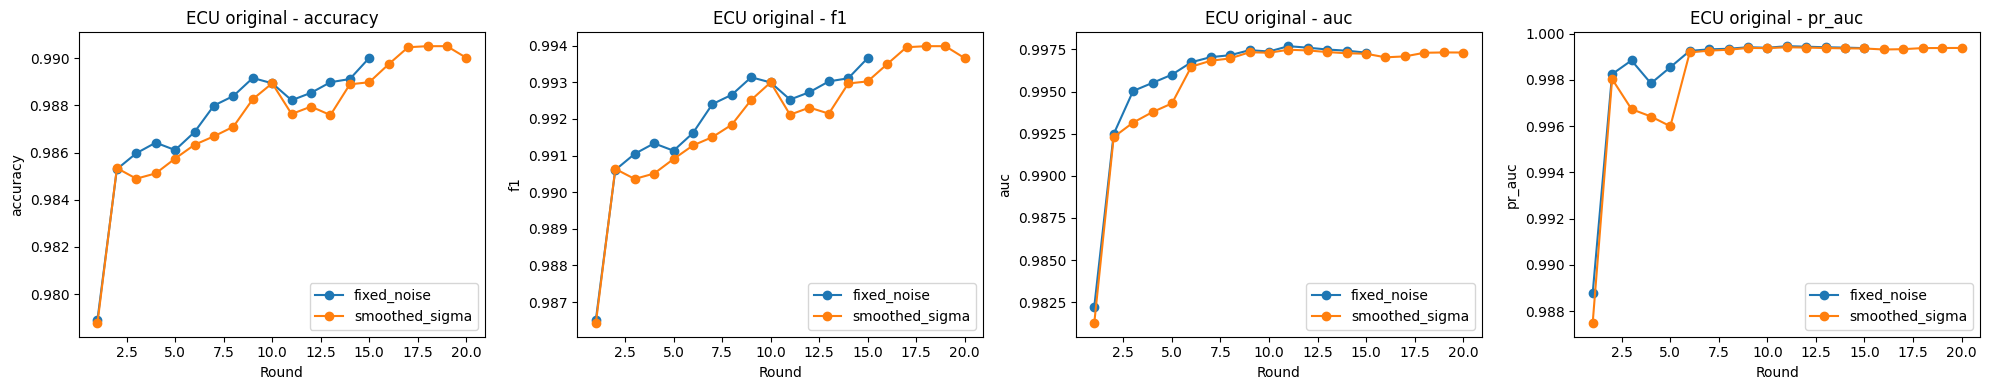

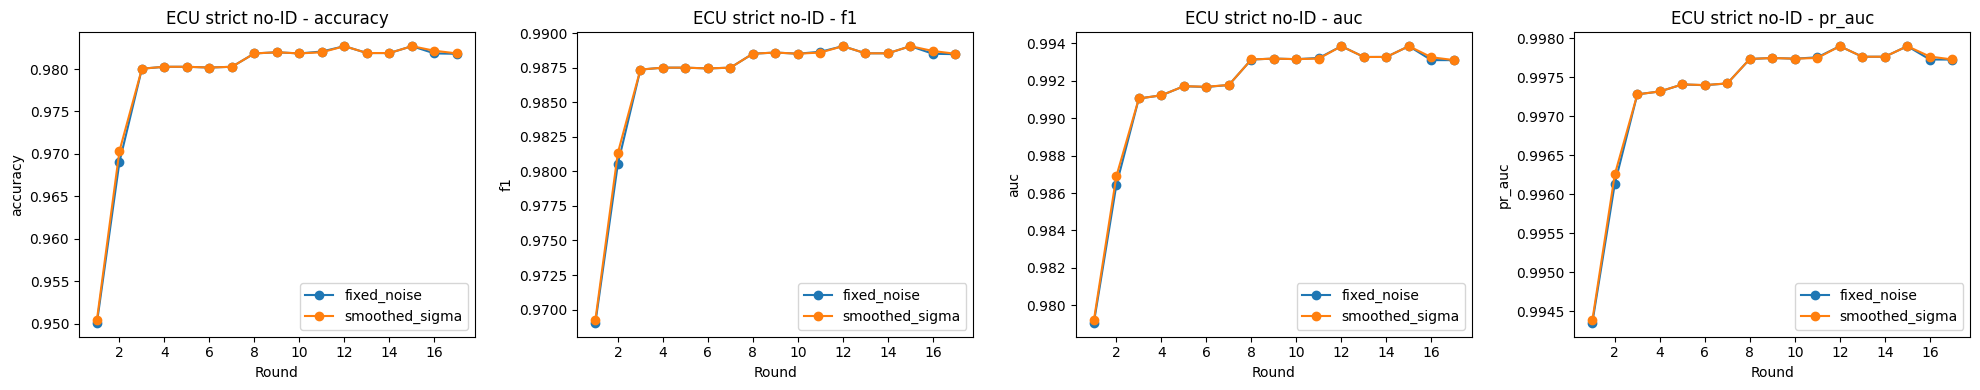

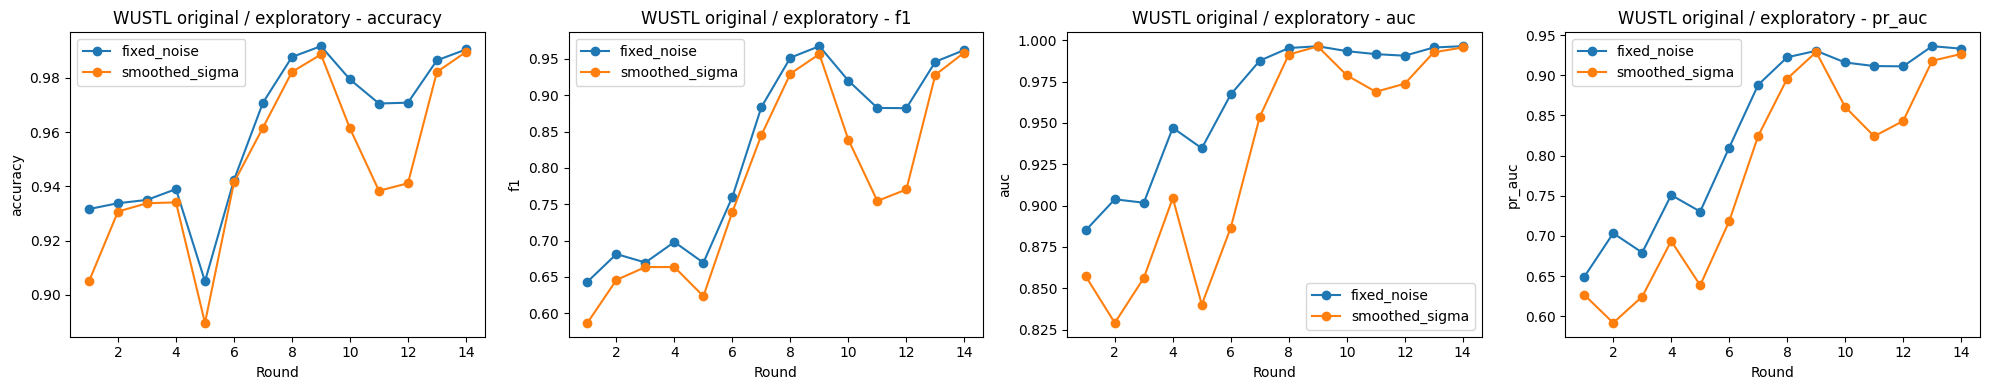

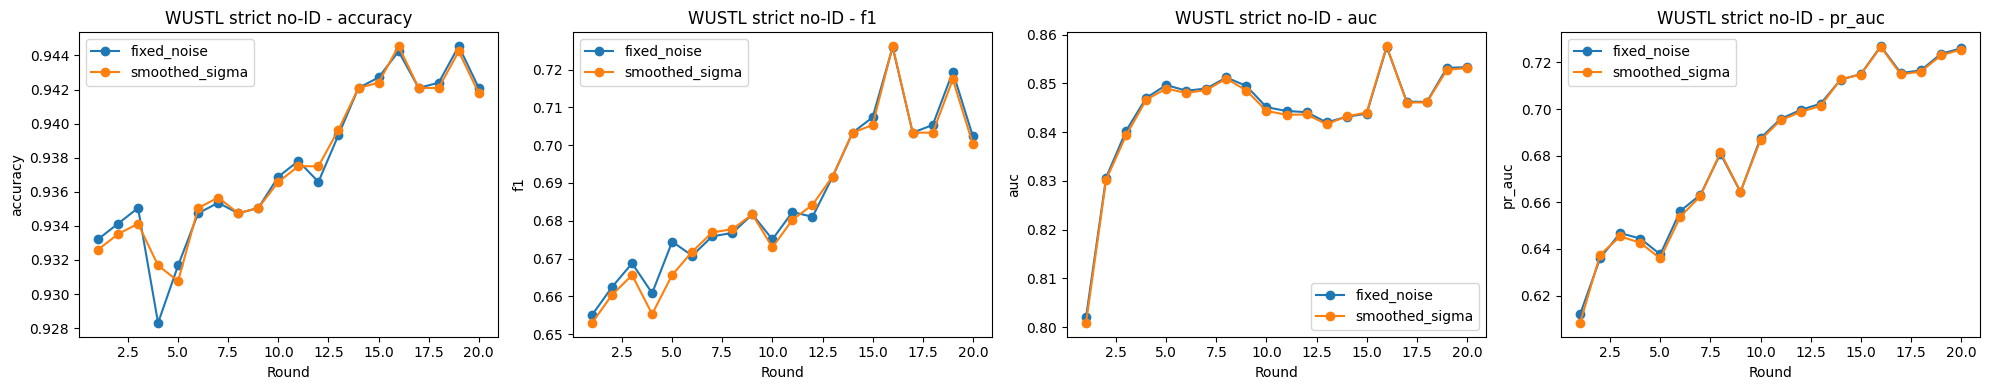

In [124]:
def plot_metric_comparison(result_a: Dict[str, Any], result_b: Dict[str, Any], title: str):
    if result_a is None or result_b is None:
        return
    hist_a = result_a["history"]
    hist_b = result_b["history"]
    label_a = result_a["summary"]["dp_strategy"]
    label_b = result_b["summary"]["dp_strategy"]

    metrics = ["accuracy", "f1", "auc", "pr_auc"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(hist_a["round"], hist_a[metric], marker="o", label=label_a)
        ax.plot(hist_b["round"], hist_b[metric], marker="o", label=label_b)
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_metric_comparison(ecu_fixed, ecu_smoothed, "ECU original")
plot_metric_comparison(ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
plot_metric_comparison(wustl_fixed, wustl_smoothed, "WUSTL original / exploratory")
plot_metric_comparison(wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")


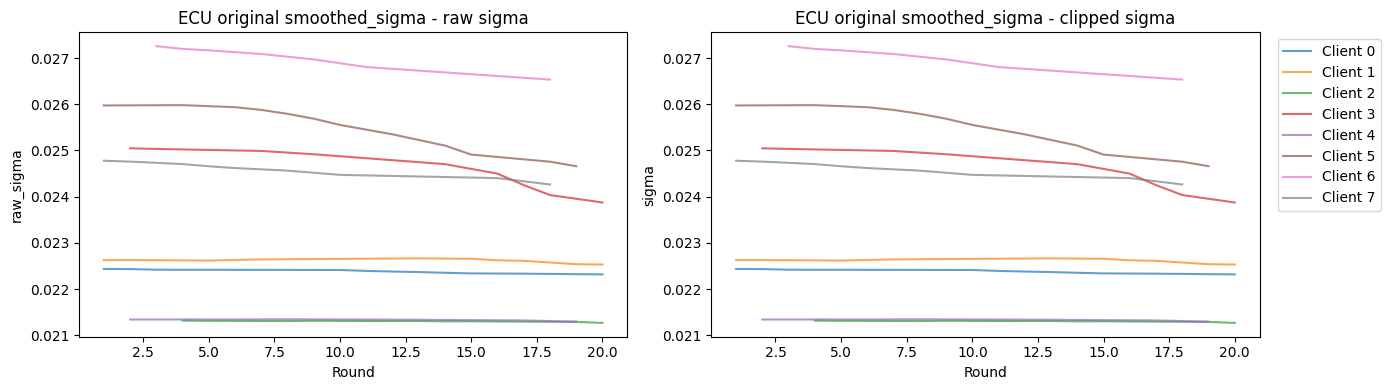

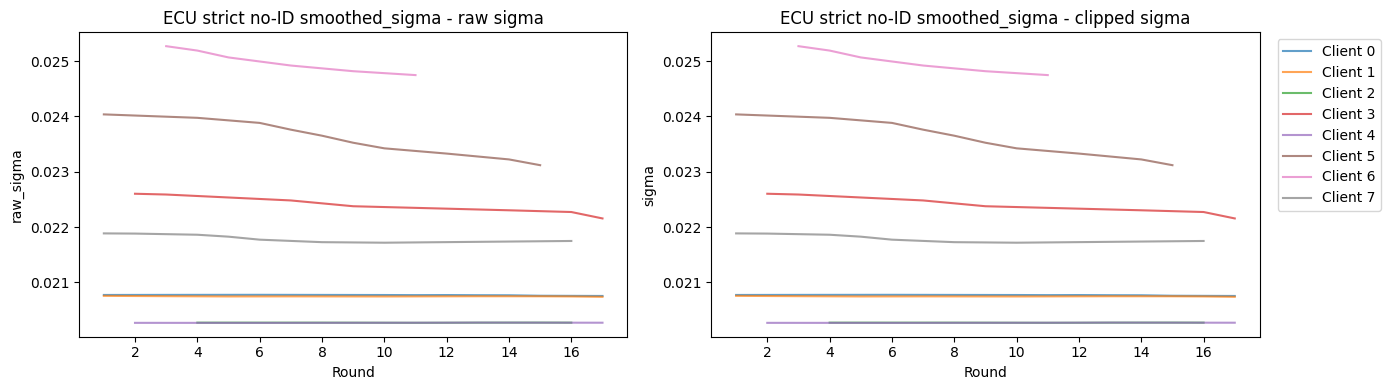

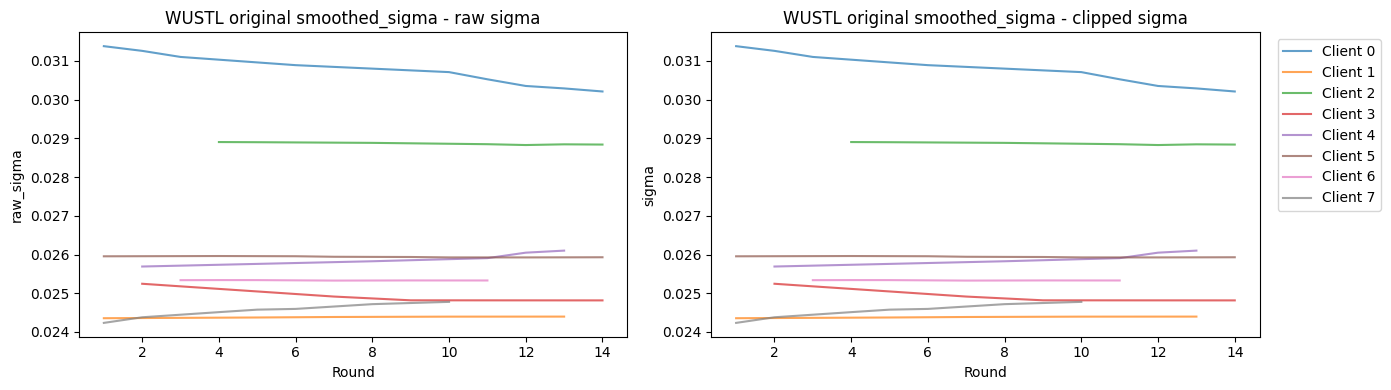

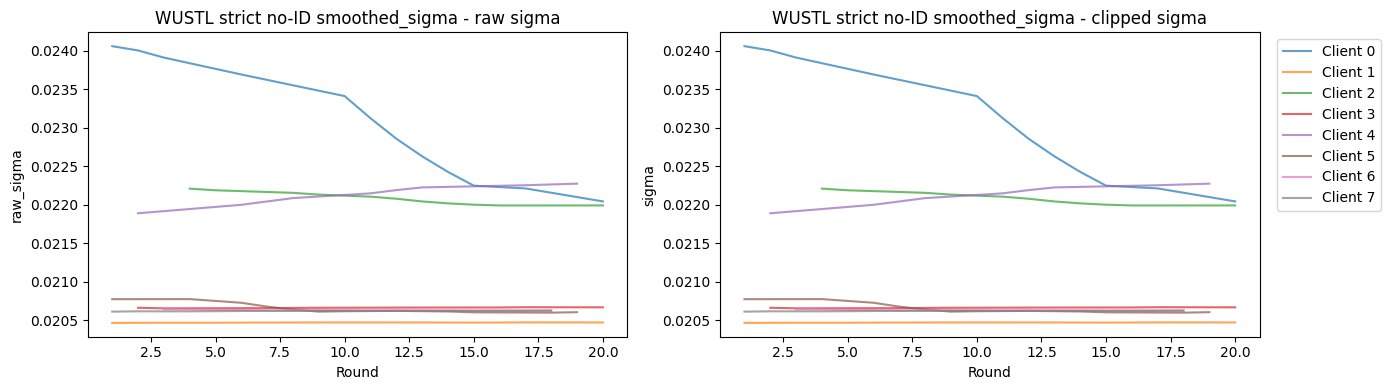

In [125]:
def plot_sigma_diagnostics(result: Dict[str, Any], title: str):
    if result is None:
        return
    log_df = result["client_log"]
    if log_df.empty:
        print("No client log available.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for cid in sorted(log_df["client_id"].unique()):
        sub = log_df[log_df["client_id"] == cid]
        axes[0].plot(sub["round"], sub["raw_sigma"], alpha=0.7, label=f"Client {cid}")
        axes[1].plot(sub["round"], sub["sigma"], alpha=0.7, label=f"Client {cid}")

    axes[0].set_title(f"{title} - raw sigma")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("raw_sigma")

    axes[1].set_title(f"{title} - clipped sigma")
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("sigma")

    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_sigma_diagnostics(ecu_smoothed, "ECU original smoothed_sigma")
plot_sigma_diagnostics(ecu_strict_smoothed, "ECU strict no-ID smoothed_sigma")
plot_sigma_diagnostics(wustl_smoothed, "WUSTL original smoothed_sigma")
plot_sigma_diagnostics(wustl_strict_smoothed, "WUSTL strict no-ID smoothed_sigma")


In [126]:
def sigma_saturation_report(result: Dict[str, Any]) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    log_df = result["client_log"]
    if log_df.empty:
        return pd.DataFrame()
    report = log_df.groupby("client_id").agg(
        raw_sigma_min=("raw_sigma", "min"),
        raw_sigma_max=("raw_sigma", "max"),
        sigma_min=("sigma", "min"),
        sigma_max=("sigma", "max"),
        sigma_nunique=("sigma", "nunique"),
        saturated_rate=("sigma_saturated", "mean"),
        raw_delta_norm_mean=("raw_delta_norm", "mean"),
        clip_norm_mean=("clip_norm_used", "mean"),
        imbalance_term_mean=("imbalance_term", "mean"),
        size_term_mean=("size_term", "mean"),
    ).reset_index()
    return report


reports = {
    "ecu_original": sigma_saturation_report(ecu_smoothed),
    "ecu_strict_no_id": sigma_saturation_report(ecu_strict_smoothed),
    "wustl_original": sigma_saturation_report(wustl_smoothed),
    "wustl_strict_no_id": sigma_saturation_report(wustl_strict_smoothed),
}

for name, report in reports.items():
    print(f"{name} saturation report")
    display(report)
    report.to_csv(RESULTS_DIR / f"{name}_sigma_saturation_report.csv", index=False)

print("Saved sigma reports in", RESULTS_DIR)


ecu_original saturation report


,client_id,raw_sigma_min,raw_sigma_max,sigma_min,sigma_max,sigma_nunique,saturated_rate,raw_delta_norm_mean,clip_norm_mean,imbalance_term_mean,size_term_mean
0,0,0.022317,0.022434,0.022317,0.022434,12,0.0,1.184306,1.0,0.758864,3.230541
1,1,0.022531,0.022664,0.022531,0.022664,11,0.0,1.364967,1.0,0.149167,2.970831
2,2,0.021268,0.021317,0.021268,0.021317,12,0.0,0.535378,1.0,0.194972,5.645724
3,3,0.023874,0.025046,0.023874,0.025046,9,0.0,2.896821,1.0,0.079153,1.390687
4,4,0.021295,0.021345,0.021295,0.021345,8,0.0,0.547088,1.0,0.208163,5.229305
5,5,0.024659,0.025981,0.024659,0.025981,12,0.0,4.390812,1.0,0.671541,0.891037
6,6,0.026534,0.027257,0.026534,0.027257,7,0.0,7.977279,1.0,0.158548,0.423586
7,7,0.024263,0.024777,0.024263,0.024777,9,0.0,3.265050,1.0,0.121156,1.637403


ecu_strict_no_id saturation report


,client_id,raw_sigma_min,raw_sigma_max,sigma_min,sigma_max,sigma_nunique,saturated_rate,raw_delta_norm_mean,clip_norm_mean,imbalance_term_mean,size_term_mean
0,0,0.020753,0.020774,0.020753,0.020774,11,0.0,0.288740,1.0,0.758864,3.230541
1,1,0.020738,0.020755,0.020738,0.020755,9,0.0,0.279282,1.0,0.149167,2.970831
2,2,0.020268,0.020272,0.020268,0.020272,10,0.0,0.094377,1.0,0.194972,5.645724
3,3,0.022155,0.022601,0.022155,0.022601,7,0.0,1.037577,1.0,0.079153,1.390687
4,4,0.020267,0.020272,0.020267,0.020272,7,0.0,0.094339,1.0,0.208163,5.229305
5,5,0.023118,0.024036,0.023118,0.024036,10,0.0,1.922704,1.0,0.671541,0.891037
6,6,0.024746,0.025269,0.024746,0.025269,6,0.0,3.689356,1.0,0.158548,0.423586
7,7,0.021716,0.021884,0.021716,0.021884,8,0.0,0.781646,1.0,0.121156,1.637403


wustl_original saturation report


,client_id,raw_sigma_min,raw_sigma_max,sigma_min,sigma_max,sigma_nunique,saturated_rate,raw_delta_norm_mean,clip_norm_mean,imbalance_term_mean,size_term_mean
0,0,0.030209,0.031378,0.030209,0.031378,9,0.0,28.900178,1.0,0.121331,0.487899
1,1,0.024355,0.024397,0.024355,0.024397,6,0.0,3.344799,1.0,0.874617,3.118520
2,2,0.028826,0.028903,0.028826,0.028903,8,0.0,17.987082,1.0,0.125383,0.854750
3,3,0.024816,0.025245,0.024816,0.025245,5,0.0,3.681384,1.0,0.087215,1.963245
4,4,0.025690,0.026100,0.025690,0.026100,6,0.0,6.787093,1.0,0.376609,0.855175
5,5,0.025925,0.025961,0.025925,0.025961,9,0.0,6.217732,1.0,0.105630,1.904186
6,6,0.025327,0.025340,0.025327,0.025340,6,0.0,4.907778,1.0,0.125383,2.000341
7,7,0.024235,0.024777,0.024235,0.024777,7,0.0,4.017384,1.0,0.652827,2.390399


wustl_strict_no_id saturation report


,client_id,raw_sigma_min,raw_sigma_max,sigma_min,sigma_max,sigma_nunique,saturated_rate,raw_delta_norm_mean,clip_norm_mean,imbalance_term_mean,size_term_mean
0,0,0.022044,0.024057,0.022044,0.024057,12,0.0,1.214210,1.0,0.121331,0.487899
1,1,0.020468,0.020475,0.020468,0.020475,11,0.0,0.171331,1.0,0.874617,3.118520
2,2,0.021991,0.022209,0.021991,0.022209,12,0.0,0.949140,1.0,0.125383,0.854750
3,3,0.020657,0.020672,0.020657,0.020672,9,0.0,0.249657,1.0,0.087215,1.963245
4,4,0.021890,0.022274,0.021890,0.022274,8,0.0,1.166033,1.0,0.376609,0.855175
5,5,0.020601,0.020777,0.020601,0.020777,12,0.0,0.221754,1.0,0.105630,1.904186
6,6,0.020631,0.020647,0.020631,0.020647,7,0.0,0.232827,1.0,0.125383,2.000341
7,7,0.020614,0.020625,0.020614,0.020625,9,0.0,0.231868,1.0,0.652827,2.390399


Saved sigma reports in adaptive_dp_results


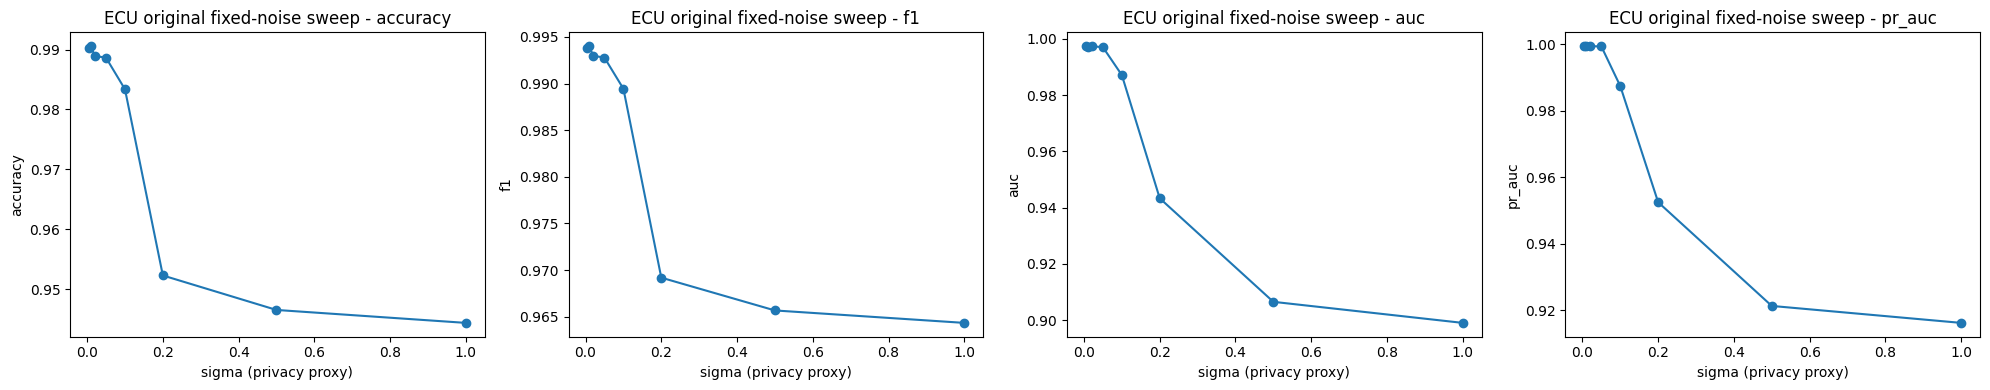

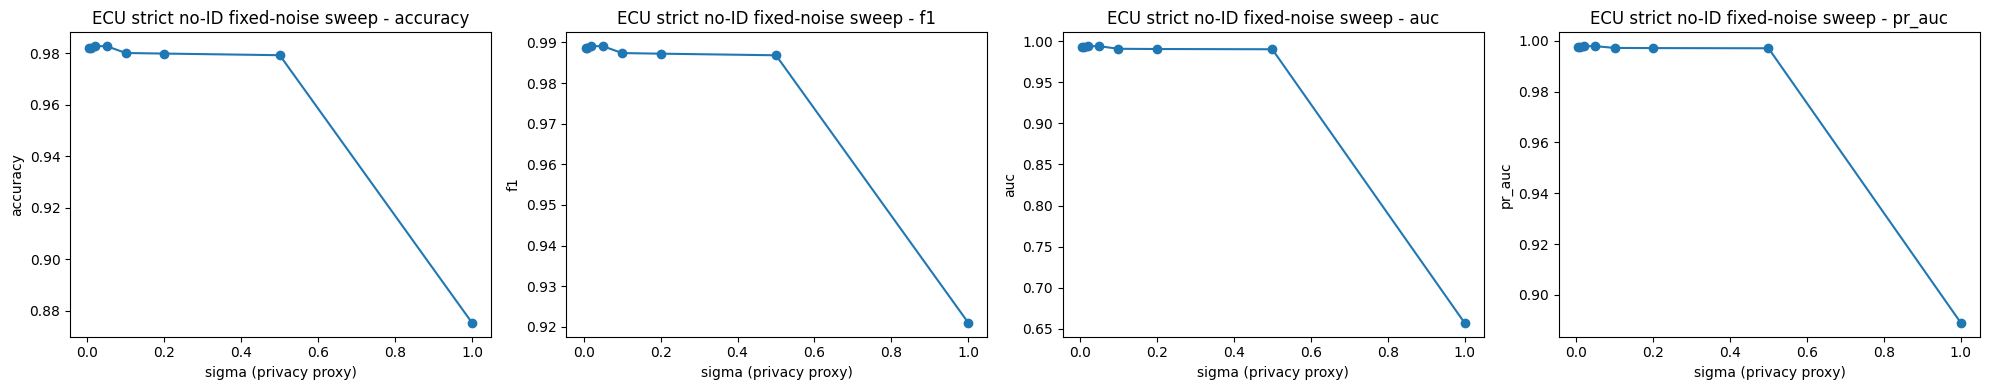

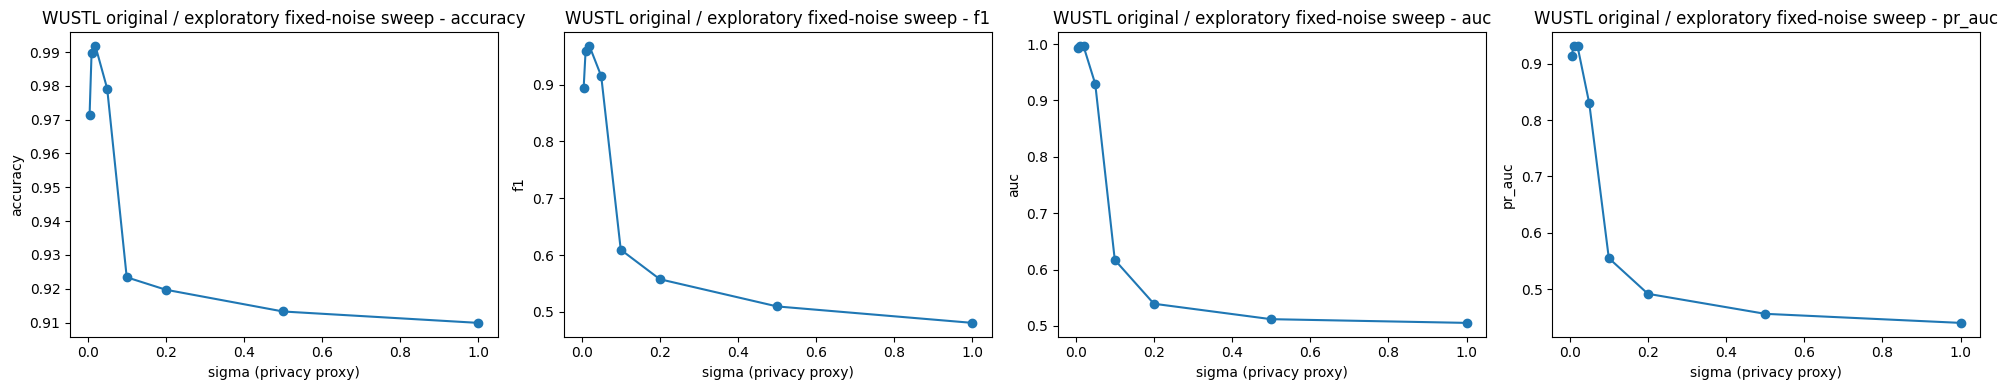

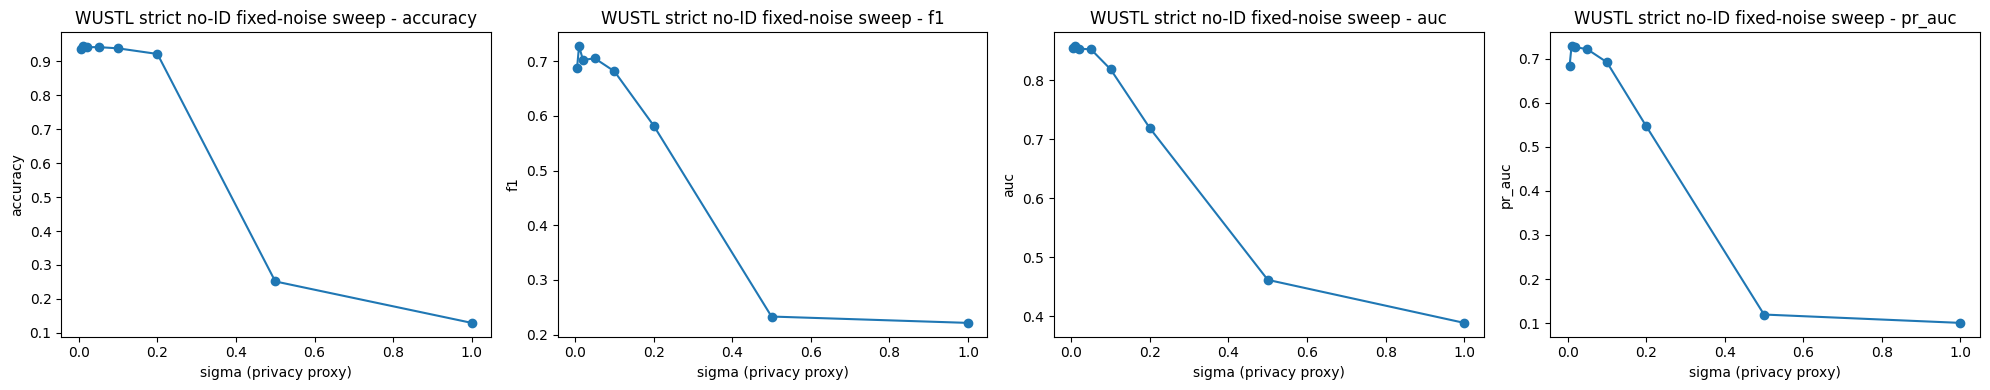

In [127]:
def plot_fixed_noise_sweep(sweep_df: pd.DataFrame, dataset_name: str):
    if sweep_df.empty:
        return
    metrics = ["accuracy", "f1", "auc", "pr_auc"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(sweep_df["sigma"], sweep_df[metric], marker="o")
        ax.set_title(f"{dataset_name} fixed-noise sweep - {metric}")
        ax.set_xlabel("sigma (privacy proxy)")
        ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()


plot_fixed_noise_sweep(ecu_fixed_sweep, "ECU original")
plot_fixed_noise_sweep(ecu_strict_fixed_sweep, "ECU strict no-ID")
plot_fixed_noise_sweep(wustl_fixed_sweep, "WUSTL original / exploratory")
plot_fixed_noise_sweep(wustl_strict_fixed_sweep, "WUSTL strict no-ID")


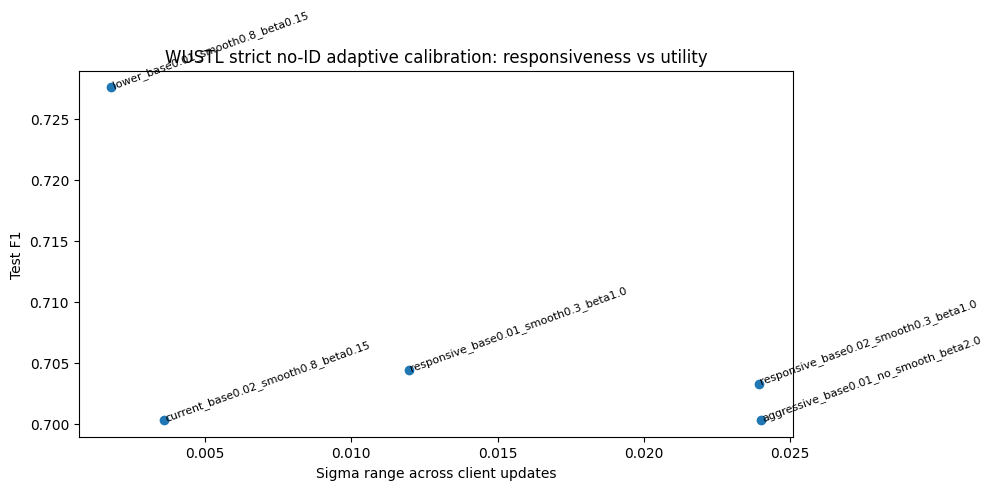

In [128]:
def plot_adaptive_calibration(calibration_df: pd.DataFrame):
    if calibration_df.empty:
        return
    plot_df = calibration_df.sort_values("sigma_range")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(plot_df["sigma_range"], plot_df["f1"])
    for _, row in plot_df.iterrows():
        ax.annotate(row["calibration_name"], (row["sigma_range"], row["f1"]), fontsize=8, rotation=20)
    ax.set_xlabel("Sigma range across client updates")
    ax.set_ylabel("Test F1")
    ax.set_title("WUSTL strict no-ID adaptive calibration: responsiveness vs utility")
    plt.tight_layout()
    plt.show()


plot_adaptive_calibration(wustl_strict_adaptive_calibration)


In [129]:
import os
import re
import pandas as pd
import numpy as np
from dataclasses import replace

MULTISEED_WUSTL_STRICT_PATH = "adaptive_dp_results/wustl_strict_multiseed_validation.csv"
os.makedirs("adaptive_dp_results", exist_ok=True)

# Use three seeds for a quick but defensible validation.
# Add more later only if you have extra time.
MULTISEED_SEEDS = [42, 123, 2025]

def safe_method_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name)

def sigma_stats_from_result(result: dict) -> dict:
    log_df = result.get("client_log", pd.DataFrame())

    if log_df is None or log_df.empty or "sigma" not in log_df.columns:
        return {
            "sigma_min": np.nan,
            "sigma_max": np.nan,
            "sigma_mean": np.nan,
            "sigma_std": np.nan,
            "sigma_range": np.nan,
            "saturated_rate": np.nan,
            "raw_delta_norm_mean": np.nan,
        }

    sigma_values = log_df["sigma"].astype(float)

    return {
        "sigma_min": float(sigma_values.min()),
        "sigma_max": float(sigma_values.max()),
        "sigma_mean": float(sigma_values.mean()),
        "sigma_std": float(sigma_values.std(ddof=0)),
        "sigma_range": float(sigma_values.max() - sigma_values.min()),
        "saturated_rate": float(log_df["sigma_saturated"].mean()) if "sigma_saturated" in log_df.columns else np.nan,
        "raw_delta_norm_mean": float(log_df["raw_delta_norm"].mean()) if "raw_delta_norm" in log_df.columns else np.nan,
    }

def build_wustl_strict_multiseed_configs(base_cfg, seed: int):
    return {
        "fedavg_no_dp": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.0,
            sigma_min=0.0,
            sigma_max=0.0,
            clip_norm=1e9,
            verbose=False,
        ),

        "fixed_sigma_0.005": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.005,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.010": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.010,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.020": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.020,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.050": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.050,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "current_adaptive_base0.02_smooth0.8_beta0.15": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.020,
            sigma_min=0.005,
            sigma_max=0.100,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=False,
        ),

        "lower_base0.01_smooth0.8_beta0.15": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.010,
            sigma_min=0.001,
            sigma_max=0.100,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=False,
        ),

        "responsive_base0.01_smooth0.3_beta1.0": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.010,
            sigma_min=0.001,
            sigma_max=0.100,
            sigma_smoothing=0.3,
            sigma_scale_beta=1.0,
            clip_norm=1.0,
            verbose=False,
        ),
    }

rows = []

for seed in MULTISEED_SEEDS:
    print(f"\n=== WUSTL strict no-ID multiseed validation: seed={seed} ===")

    configs = build_wustl_strict_multiseed_configs(base_cfg, seed)

    for method, cfg in configs.items():
        print(f"Running {method}...")

        result = run_experiment(wustl_strict_bundle, cfg)

        row = {
            "dataset": "WUSTL_strict_no_id",
            "seed": seed,
            "method": method,
            "dp_strategy": cfg.dp_strategy,
            "base_sigma": cfg.base_sigma,
            "sigma_smoothing": cfg.sigma_smoothing,
            "sigma_scale_beta": cfg.sigma_scale_beta,
            "sigma_min_setting": cfg.sigma_min,
            "sigma_max_setting": cfg.sigma_max,
            **result["summary"],
            **sigma_stats_from_result(result),
        }

        rows.append(row)

wustl_strict_multiseed_results = pd.DataFrame(rows)

display(wustl_strict_multiseed_results.sort_values(["seed", "method"]))

wustl_strict_multiseed_results.to_csv(
    MULTISEED_WUSTL_STRICT_PATH,
    index=False,
)

print(f"\nSaved: {MULTISEED_WUSTL_STRICT_PATH}")


=== WUSTL strict no-ID multiseed validation: seed=42 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Running responsive_base0.01_smooth0.3_beta1.0...

=== WUSTL strict no-ID multiseed validation: seed=123 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Running responsive_base0.01_smooth0.3_beta1.0...

=== WUSTL strict no-ID multiseed validation: seed=2025 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Ru

,dataset,seed,method,dp_strategy,base_sigma,sigma_smoothing,sigma_scale_beta,sigma_min_setting,sigma_max_setting,best_round,...,pr_auc,threshold,val_f1,sigma_min,sigma_max,sigma_mean,sigma_std,sigma_range,saturated_rate,raw_delta_norm_mean
5,WUSTL_strict_no_id,42,current_adaptive_base0.02_smooth0.8_beta0.15,smoothed_sigma,0.020,0.8,0.15,0.005,0.1,20,...,0.725513,0.050000,0.682540,0.020468,0.024057,0.021346,9.943388e-04,0.003588,0.0,0.572471
0,WUSTL_strict_no_id,42,fedavg_no_dp,fixed_noise,0.000,0.8,0.15,0.000,0.0,5,...,0.698528,0.002036,0.689922,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.0,0.549618
1,WUSTL_strict_no_id,42,fixed_sigma_0.005,fixed_noise,0.005,0.8,0.15,0.000,1.0,9,...,0.683001,0.018300,0.682171,0.005000,0.005000,0.005000,0.000000e+00,0.000000,0.0,0.612361
2,WUSTL_strict_no_id,42,fixed_sigma_0.010,fixed_noise,0.010,0.8,0.15,0.000,1.0,16,...,0.728133,0.001968,0.687500,0.010000,0.010000,0.010000,1.734723e-18,0.000000,0.0,0.570792
3,WUSTL_strict_no_id,42,fixed_sigma_0.020,fixed_noise,0.020,0.8,0.15,0.000,1.0,20,...,0.726034,0.050000,0.682540,0.020000,0.020000,0.020000,3.469447e-18,0.000000,0.0,0.571168
4,WUSTL_strict_no_id,42,fixed_sigma_0.050,fixed_noise,0.050,0.8,0.15,0.000,1.0,16,...,0.721159,0.003155,0.679842,0.050000,0.050000,0.050000,6.938894e-18,0.000000,0.0,0.573869
6,WUSTL_strict_no_id,42,lower_base0.01_smooth0.8_beta0.15,smoothed_sigma,0.010,0.8,0.15,0.001,0.1,16,...,0.728169,0.001950,0.687500,0.010234,0.012028,0.010671,4.964040e-04,0.001794,0.0,0.570125
7,WUSTL_strict_no_id,42,responsive_base0.01_smooth0.3_beta1.0,smoothed_sigma,0.010,0.3,1.00,0.001,0.1,20,...,0.725411,0.050000,0.682540,0.011558,0.023522,0.014102,2.929984e-03,0.011963,0.0,0.569811
13,WUSTL_strict_no_id,123,current_adaptive_base0.02_smooth0.8_beta0.15,smoothed_sigma,0.020,0.8,0.15,0.005,0.1,17,...,0.726257,0.050000,0.682540,0.020453,0.024115,0.021446,1.026142e-03,0.003662,0.0,0.617543
8,WUSTL_strict_no_id,123,fedavg_no_dp,fixed_noise,0.000,0.8,0.15,0.000,0.0,11,...,0.717014,0.050000,0.682540,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.0,0.548056



Saved: adaptive_dp_results/wustl_strict_multiseed_validation.csv


In [130]:
multiseed_summary = (
    wustl_strict_multiseed_results
    .groupby("method")
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        val_f1_mean=("val_f1", "mean"),
        val_f1_std=("val_f1", "std"),
        sigma_mean=("sigma_mean", "mean"),
        sigma_range_mean=("sigma_range", "mean"),
        sigma_std_mean=("sigma_std", "mean"),
    )
    .reset_index()
    .sort_values("f1_mean", ascending=False)
)

display(multiseed_summary)

multiseed_summary.to_csv(
    "adaptive_dp_results/wustl_strict_multiseed_summary.csv",
    index=False,
)

print("Saved adaptive_dp_results/wustl_strict_multiseed_summary.csv")

slide_cols = [
    "method",
    "f1_mean",
    "f1_std",
    "pr_auc_mean",
    "pr_auc_std",
    "val_f1_mean",
    "sigma_mean",
    "sigma_range_mean",
]

slide_table = multiseed_summary[slide_cols].copy()

for col in slide_table.columns:
    if col != "method":
        slide_table[col] = slide_table[col].round(4)

display(slide_table)

slide_table.to_csv(
    "adaptive_dp_results/wustl_strict_multiseed_slide_table.csv",
    index=False,
)

print("Saved adaptive_dp_results/wustl_strict_multiseed_slide_table.csv")

,method,f1_mean,f1_std,auc_mean,auc_std,pr_auc_mean,pr_auc_std,val_f1_mean,val_f1_std,sigma_mean,sigma_range_mean,sigma_std_mean
4,fixed_sigma_0.020,0.716575,0.013822,0.853773,0.009202,0.726951,0.009505,0.686736,0.003794,0.020000,0.000000,2.312965e-18
7,responsive_base0.01_smooth0.3_beta1.0,0.714808,0.011573,0.855137,0.009246,0.725741,0.012487,0.685847,0.002864,0.014117,0.011934,2.932889e-03
3,fixed_sigma_0.010,0.714364,0.013146,0.850126,0.009555,0.722045,0.008351,0.687560,0.002332,0.010000,0.000000,1.156482e-18
0,current_adaptive_base0.02_smooth0.8_beta0.15,0.713224,0.011411,0.848787,0.004354,0.723428,0.004272,0.684275,0.003006,0.021360,0.003580,1.001209e-03
6,lower_base0.01_smooth0.8_beta0.15,0.709602,0.015555,0.848164,0.009209,0.717153,0.009584,0.684977,0.002676,0.010681,0.001790,5.082199e-04
5,fixed_sigma_0.050,0.708436,0.013108,0.845810,0.008850,0.717097,0.008746,0.682447,0.004376,0.050000,0.000000,9.251859e-18
1,fedavg_no_dp,0.707844,0.003092,0.846564,0.007345,0.708839,0.009426,0.684101,0.005219,0.000000,0.000000,0.000000e+00
2,fixed_sigma_0.005,0.702613,0.015551,0.850398,0.008715,0.707655,0.022512,0.685784,0.003903,0.005000,0.000000,2.891206e-19


Saved adaptive_dp_results/wustl_strict_multiseed_summary.csv


,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,val_f1_mean,sigma_mean,sigma_range_mean
4,fixed_sigma_0.020,0.7166,0.0138,0.7270,0.0095,0.6867,0.0200,0.0000
7,responsive_base0.01_smooth0.3_beta1.0,0.7148,0.0116,0.7257,0.0125,0.6858,0.0141,0.0119
3,fixed_sigma_0.010,0.7144,0.0131,0.7220,0.0084,0.6876,0.0100,0.0000
0,current_adaptive_base0.02_smooth0.8_beta0.15,0.7132,0.0114,0.7234,0.0043,0.6843,0.0214,0.0036
6,lower_base0.01_smooth0.8_beta0.15,0.7096,0.0156,0.7172,0.0096,0.6850,0.0107,0.0018
5,fixed_sigma_0.050,0.7084,0.0131,0.7171,0.0087,0.6824,0.0500,0.0000
1,fedavg_no_dp,0.7078,0.0031,0.7088,0.0094,0.6841,0.0000,0.0000
2,fixed_sigma_0.005,0.7026,0.0156,0.7077,0.0225,0.6858,0.0050,0.0000


Saved adaptive_dp_results/wustl_strict_multiseed_slide_table.csv


## Graph collection for presentation

In [131]:
from dataclasses import replace

# Fetch the No DP dictionaries explicitly so they are defined
ecu_no_dp = run_experiment_cached(
    ecu_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
ecu_strict_no_dp = run_experiment_cached(
    ecu_strict_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
wustl_no_dp = run_experiment_cached(
    wustl_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
wustl_strict_no_dp = run_experiment_cached(
    wustl_strict_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)

Running experiment: ECU / fedavg_no_dp
Running experiment: ECU_strict_no_id / fedavg_no_dp
Running experiment: WUSTL / fedavg_no_dp
Running experiment: WUSTL_strict_no_id / fedavg_no_dp


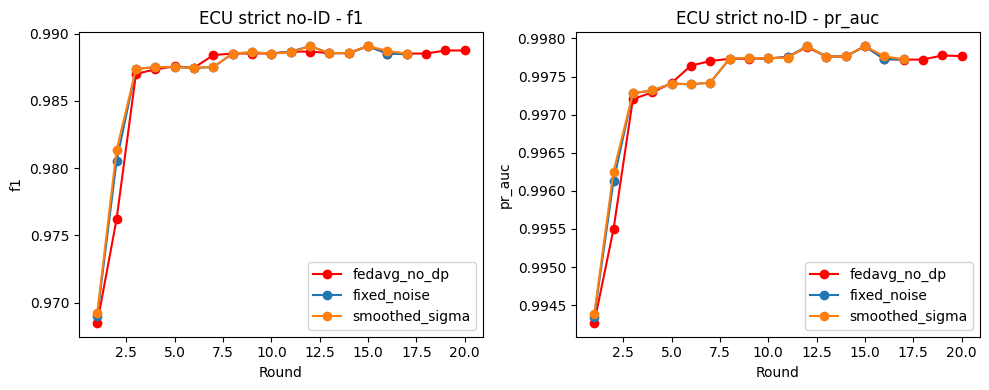

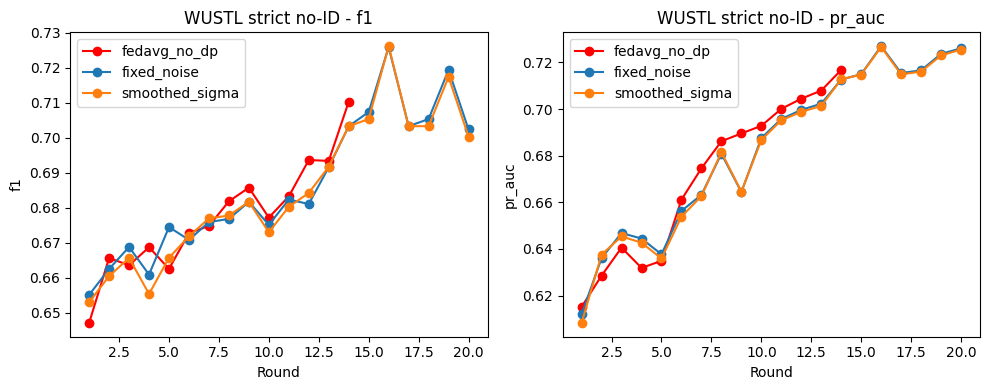

In [132]:
def plot_metric_comparison_triplet(result_no_dp: Dict[str, Any], result_fixed: Dict[str, Any], result_smoothed: Dict[str, Any], title: str):
    if result_no_dp is None or result_fixed is None or result_smoothed is None:
        print(f"Skipping {title} - Missing data.")
        return
        
    hist_no_dp = result_no_dp["history"]
    hist_fixed = result_fixed["history"]
    hist_smoothed = result_smoothed["history"]
    
    label_no_dp = "fedavg_no_dp" 
    label_fixed = result_fixed["summary"]["dp_strategy"]
    label_smoothed = result_smoothed["summary"]["dp_strategy"]

    metrics = [ "f1", "pr_auc"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, metric in zip(axes, metrics):
        # No DP in Red
        ax.plot(hist_no_dp["round"], hist_no_dp[metric], marker="o", label=label_no_dp, color="red")
        
        # Fixed and Smoothed blue/orange
        ax.plot(hist_fixed["round"], hist_fixed[metric], marker="o", label=label_fixed)
        ax.plot(hist_smoothed["round"], hist_smoothed[metric], marker="o", label=label_smoothed)
        
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.legend()
        
    plt.tight_layout()
    plt.show()

# plot_metric_comparison_triplet(ecu_no_dp, ecu_fixed, ecu_smoothed, "ECU original")
plot_metric_comparison_triplet(ecu_strict_no_dp, ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
# plot_metric_comparison_triplet(wustl_no_dp, wustl_fixed, wustl_smoothed, "WUSTL original / exploratory")
plot_metric_comparison_triplet(wustl_strict_no_dp, wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")

In [139]:
cfg_no_dp_final = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.0,
    sigma_min=0.0,
    sigma_max=0.0,
    clip_norm=1e9,
    verbose=ROUND_VERBOSE,
)

cfg_fixed_001 = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.01,
    sigma_min=0.01,
    sigma_max=0.01,
    verbose=ROUND_VERBOSE,
)

cfg_smoothed_final = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.01,
    sigma_min=0.005,
    sigma_max=0.05,
    verbose=ROUND_VERBOSE,
)

In [140]:
ecu_grouped_no_dp = run_experiment_cached(
    ecu_grouped_bundle,
    cfg_no_dp_final,
    label="FINAL_no_dp",
)

ecu_grouped_fixed = run_experiment_cached(
    ecu_grouped_bundle,
    cfg_fixed_001,
    label="FINAL_fixed_sigma_0.01",
)

ecu_grouped_smoothed = run_experiment_cached(
    ecu_grouped_bundle,
    cfg_smoothed_final,
    label="FINAL_smoothed_sigma_base_0.01",
)

wustl_strict_no_dp_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_no_dp_final,
    label="FINAL_no_dp",
)

wustl_strict_fixed_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_fixed_001,
    label="FINAL_fixed_sigma_0.01",
)

wustl_strict_smoothed_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_smoothed_final,
    label="FINAL_smoothed_sigma_base_0.01",
)

Running experiment: ECU Grouped Strict / FINAL_no_dp
Running experiment: ECU Grouped Strict / FINAL_fixed_sigma_0.01
Running experiment: ECU Grouped Strict / FINAL_smoothed_sigma_base_0.01
Running experiment: WUSTL_strict_no_id / FINAL_no_dp
Running experiment: WUSTL_strict_no_id / FINAL_fixed_sigma_0.01
Running experiment: WUSTL_strict_no_id / FINAL_smoothed_sigma_base_0.01


In [141]:
final_utility_results = pd.DataFrame([
    ecu_grouped_no_dp["summary"],
    ecu_grouped_fixed["summary"],
    ecu_grouped_smoothed["summary"],
    wustl_strict_no_dp_final["summary"],
    wustl_strict_fixed_final["summary"],
    wustl_strict_smoothed_final["summary"],
])

display(final_utility_results)

final_utility_results.to_csv(
    RESULTS_DIR / "final_utility_results.csv",
    index=False,
)

,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
0,ECU Grouped Strict,fixed_noise,1,0.992565,0.998840,0.991176,0.994993,0.997068,0.998871,0.496110,0.984970
1,ECU Grouped Strict,fixed_noise,8,0.993280,0.999613,0.991368,0.995473,0.998333,0.999304,0.443864,0.985457
2,ECU Grouped Strict,smoothed_sigma,8,0.993423,0.999613,0.991560,0.995570,0.998392,0.999324,0.440966,0.985579
3,WUSTL_strict_no_id,fixed_noise,5,0.939951,0.914397,0.574572,0.705706,0.854961,0.698528,0.002036,0.689922
4,WUSTL_strict_no_id,fixed_noise,16,0.945159,0.963710,0.584352,0.727549,0.857563,0.728133,0.001968,0.687500
5,WUSTL_strict_no_id,smoothed_sigma,16,0.945159,0.963710,0.584352,0.727549,0.857822,0.728169,0.001950,0.687500


In [142]:
def adaptive_sigma_report(result, name):
    print(f"\n{name}")

    if "client_log" not in result:
        print("No client_log found.")
        return

    log = result["client_log"]

    if "sigma" not in log.columns:
        print("No sigma column found.")
        return

    sig = log["sigma"].astype(float)

    print("sigma min: ", sig.min())
    print("sigma max: ", sig.max())
    print("sigma mean:", sig.mean())
    print("sigma std: ", sig.std(ddof=0))

    cols = [
        "client_id",
        "round",
        "sigma",
        "raw_delta_norm",
        "client_n",
        "client_pos_rate",
    ]
    cols = [c for c in cols if c in log.columns]

    display(
        log[cols]
        .groupby("client_id")
        .agg(["count", "mean", "min", "max"])
    )


adaptive_sigma_report(ecu_grouped_smoothed, "ECU Grouped Smoothed Sigma")
adaptive_sigma_report(wustl_strict_smoothed_final, "WUSTL Strict Smoothed Sigma")


ECU Grouped Smoothed Sigma
sigma min:  0.010651889878665229
sigma max:  0.012431722406184008
sigma mean: 0.011585902297110852
sigma std:  0.0004193545703456365


round                   sigma                                \
          count      mean min max count      mean       min       max   
client_id                                                               
0             8  7.250000   1  13     8  0.010847  0.010652  0.010933   
1             6  6.500000   1  13     6  0.012181  0.011808  0.012432   
2             7  8.857143   4  13     7  0.011680  0.011527  0.011786   
3             4  5.250000   2   9     4  0.011735  0.011674  0.011788   
4             6  8.666667   2  13     6  0.011601  0.011444  0.011755   
5             8  7.125000   1  12     8  0.011548  0.011198  0.011860   
6             6  6.500000   3  11     6  0.011338  0.011227  0.011400   
7             7  5.142857   1  10     7  0.011983  0.011767  0.012169   

          raw_delta_norm                               client_n           \
                   count      mean       min       max    count     mean   
client_id                                                                  
0                      8  0.603663  0.207911  0.862571        8   2443.0   
1                      6  2.177751  0.382853  4.058896        6  29154.0   
2                      7  1.771881  1.341586  2.290164        7  12237.0   
3                      4  1.939496  1.654897  2.293652        4   9964.0   
4                      6  1.513918  1.134378  2.221139        6   8956.0   
5                      8  1.218762  0.422583  2.455510        8   9550.0   
6                      6  1.258077  0.800710  1.542142        6   5476.0   
7                      7  2.197007  1.486736  3.245022        7  16011.0   

                        client_pos_rate                                
             min    max           count      mean       min       max  
client_id                                                              
0           2443   2443               8  0.983627  0.983627  0.983627  
1          29154  29154               6  0.968100  0.968100  0.968100  
2          12237  12237               7  0.999673  0.999673  0.999673  
3           9964   9964               4  0.251104  0.251104  0.251104  
4           8956   8956               6  0.576038  0.576038  0.576038  
5           9550   9550               8  0.947958  0.947958  0.947958  
6           5476   5476               6  0.989226  0.989226  0.989226  
7          16011  16011               7  0.580538  0.580538  0.580538


WUSTL Strict Smoothed Sigma
sigma min:  0.01023416867800153
sigma max:  0.012028269722444642
sigma mean: 0.010671436118228572
sigma std:  0.0004964039989803605


round                    sigma                                \
          count       mean min max count      mean       min       max   
client_id                                                                
0            12  10.333333   1  20    12  0.011522  0.011005  0.012028   
1            11  11.454545   1  20    11  0.010236  0.010234  0.010238   
2            12  12.166667   4  20    12  0.011026  0.010985  0.011091   
3             9  11.777778   2  20     9  0.010334  0.010329  0.010336   
4             8  11.000000   2  19     8  0.011074  0.010946  0.011142   
5            12  10.250000   1  19    12  0.010328  0.010299  0.010388   
6             7   8.142857   3  18     7  0.010317  0.010313  0.010323   
7             9   7.777778   1  18     9  0.010311  0.010307  0.010313   

          raw_delta_norm                               client_n                \
                   count      mean       min       max    count    mean   min   
client_id                                                                       
0                     12  1.203230  0.500456  2.865843       12  6169.0  6169   
1                     11  0.171457  0.168392  0.174804       11   151.0   151   
2                     12  0.937241  0.858344  1.069213       12  2010.0  2010   
3                      9  0.250028  0.234338  0.255615        9   381.0   381   
4                      8  1.178908  0.879391  1.254759        8  2008.0  2008   
5                     12  0.221067  0.170518  0.295251       12   405.0   405   
6                      7  0.230520  0.221241  0.240002        7   367.0   367   
7                      9  0.232263  0.227142  0.236551        9   257.0   257   

                client_pos_rate                                
            max           count      mean       min       max  
client_id                                                      
0          6169              12  0.004053  0.004053  0.004053  
1           151              11  1.000000  1.000000  1.000000  
2          2010              12  0.000000  0.000000  0.000000  
3           381               9  0.212598  0.212598  0.212598  
4          2008               8  0.501992  0.501992  0.501992  
5           405              12  0.019753  0.019753  0.019753  
6           367               7  0.000000  0.000000  0.000000  
7           257               9  0.778210  0.778210  0.778210

## White-box membership inference attack
This attack uses final-model white-box features:
- per-sample loss
- posterior/confidence/entropy
- correctness
- gradient summary statistics


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def _finite_tensor(t: torch.Tensor) -> torch.Tensor:
    """Replace NaN/Inf values so the sklearn attacker never receives invalid features."""
    
    return torch.nan_to_num(t, nan=0.0, posinf=1e6, neginf=-1e6)


def _finite_array(x: np.ndarray) -> np.ndarray:
    """Replace NaN/Inf values in numpy arrays."""
    
    return np.nan_to_num(x, nan=0.0, posinf=1e6, neginf=-1e6)


def extract_white_box_features(model: torch.nn.Module, x: torch.Tensor, y: torch.Tensor) -> np.ndarray:
    """
    Extract compact white-box MIA features for one sample.

    BinaryMLP binary classification:
      - model output is a single logit
      - labels are 0/1
      - training loss is BCEWithLogitsLoss
    """
    
    model.eval()
    model.zero_grad(set_to_none=True)

    x = x.float()
    y = y.float().view(-1)

    logits = _finite_tensor(model(x).view(-1))
    probs = torch.sigmoid(logits)

    loss = F.binary_cross_entropy_with_logits(logits, y, reduction="mean")
    loss = _finite_tensor(loss)
    loss.backward()

    eps = 1e-12
    p = probs.detach().clamp(eps, 1.0 - eps)

    true_conf = torch.where(y == 1, p, 1.0 - p)
    pred = (p >= 0.5).float()
    correct = (pred == y).float()
    entropy = -(p * torch.log(p) + (1.0 - p) * torch.log(1.0 - p))

    scalar_features = [
        loss.detach().view(1),
        p.detach().view(1),
        (1.0 - p).detach().view(1),
        true_conf.detach().view(1),
        correct.detach().view(1),
        entropy.detach().view(1),
        logits.detach().view(1),
    ]

    grad_features = []
    raw_grads = []

    for param in model.parameters():
        if param.grad is None:
            continue

        g = _finite_tensor(param.grad.detach().flatten())
        raw_grads.append(g)

        grad_features.extend([
            torch.linalg.vector_norm(g, ord=2).view(1),
            g.abs().mean().view(1),
            g.abs().max().view(1),
            g.mean().view(1),
            g.std(unbiased=False).view(1),
        ])

    if raw_grads:
        flat_grad = _finite_tensor(torch.cat(raw_grads))

        grad_features.extend([
            torch.linalg.vector_norm(flat_grad, ord=2).view(1),
            flat_grad.abs().mean().view(1),
            flat_grad.abs().max().view(1),
            flat_grad.mean().view(1),
            flat_grad.std(unbiased=False).view(1),
        ])

    features = torch.cat(scalar_features + grad_features)
    features = _finite_tensor(features)

    return features.detach().cpu().numpy().astype(np.float32)

## Attack dataset construction and attacker training

Members are sampled from the target model's training split.
Non-members are sampled from the target model's test split.

The attacker is trained and evaluated on a held-out split of the attack dataset,
so the MIA score is not measured on the attacker's own training examples.

In [ ]:
def _balanced_sample_indices(y: np.ndarray, n_per_class: int, seed: int = 42) -> np.ndarray:
    """Sample up to n_per_class examples per target class."""
    
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)

    selected = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        selected.extend(idx[:min(n_per_class, len(idx))])

    rng.shuffle(selected)
    return np.asarray(selected, dtype=int)


def _safe_attack_split(X_attack, y_attack, target_y, test_size=0.3, seed=42):
    """
    Prefer stratifying by membership and target label.
    Fall back to membership-only stratification if a stratum is too small.
    """
    
    full_strata = np.array([f"{m}_{t}" for m, t in zip(y_attack, target_y)])
    _, counts = np.unique(full_strata, return_counts=True)

    stratify = full_strata if counts.min() >= 2 else y_attack

    return train_test_split(
        X_attack,
        y_attack,
        test_size=test_size,
        random_state=seed,
        stratify=stratify,
    )


def build_attack_matrix(
    target_model,
    bundle,
    num_per_target_class=500,
    seed=42,
    member_indices=None,
    nonmember_indices=None,
):
    """
    Build the MIA dataset.

    Default mode:
      - members: balanced sample from bundle["X_train"]
      - non-members: balanced sample from bundle["X_test"]

    Exact-index mode:
      - pass member_indices and nonmember_indices directly
      - used for the overfit positive-control diagnostic
    """
    
    target_model.eval()
    target_model.to(DEVICE)

    if member_indices is None:
        member_indices = _balanced_sample_indices(
            bundle["y_train"],
            n_per_class=num_per_target_class,
            seed=seed,
        )
    else:
        member_indices = np.asarray(member_indices, dtype=int)

    if nonmember_indices is None:
        nonmember_indices = _balanced_sample_indices(
            bundle["y_test"],
            n_per_class=num_per_target_class,
            seed=seed + 1,
        )
    else:
        nonmember_indices = np.asarray(nonmember_indices, dtype=int)

    X_member = torch.tensor(bundle["X_train"][member_indices], dtype=torch.float32)
    y_member = torch.tensor(bundle["y_train"][member_indices], dtype=torch.float32)

    X_nonmember = torch.tensor(bundle["X_test"][nonmember_indices], dtype=torch.float32)
    y_nonmember = torch.tensor(bundle["y_test"][nonmember_indices], dtype=torch.float32)

    attack_features = []
    attack_membership = []
    attack_target_labels = []

    def add_sample(x, y, membership_label):
        x = x.unsqueeze(0).to(DEVICE)
        y = y.view(1).to(DEVICE)

        features = extract_white_box_features(target_model, x, y)
        features = _finite_array(features)

        attack_features.append(features)
        attack_membership.append(membership_label)
        attack_target_labels.append(int(y.item()))

    for x, y in TensorDataset(X_member, y_member):
        add_sample(x, y, membership_label=1)

    for x, y in TensorDataset(X_nonmember, y_nonmember):
        add_sample(x, y, membership_label=0)

    X_attack = _finite_array(np.vstack(attack_features).astype(np.float32))
    y_attack = np.asarray(attack_membership).astype(int)
    target_y = np.asarray(attack_target_labels).astype(int)

    return X_attack, y_attack, target_y


def run_whitebox_mia(
    target_model,
    bundle,
    num_per_target_class=500,
    seed=42,
    member_indices=None,
    nonmember_indices=None,
):
    """
    Run a final-model white-box MIA.

    Main reported metrics:
      - mia_accuracy: thresholded attack accuracy
      - mia_auc: threshold-free attack separability
      - mia_advantage: max(0, 2*AUC - 1)
      - loss_only_auc: sanity baseline using only negative loss
    """
    X_attack, y_attack, target_y = build_attack_matrix(
        target_model=target_model,
        bundle=bundle,
        num_per_target_class=num_per_target_class,
        seed=seed,
        member_indices=member_indices,
        nonmember_indices=nonmember_indices,
    )

    X_train_att, X_test_att, y_train_att, y_test_att = _safe_attack_split(
        X_attack,
        y_attack,
        target_y,
        test_size=0.3,
        seed=seed,
    )

    attack_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    )

    attack_model.fit(X_train_att, y_train_att)

    member_scores = attack_model.predict_proba(X_test_att)[:, 1]
    member_preds = (member_scores >= 0.5).astype(int)

    mia_auc = roc_auc_score(y_test_att, member_scores)

    # Feature 0 is per-sample loss. Members usually have lower loss.
    loss_only_scores = -X_test_att[:, 0]
    loss_only_auc = roc_auc_score(y_test_att, loss_only_scores)

    return {
        "mia_accuracy": float(accuracy_score(y_test_att, member_preds)),
        "mia_balanced_accuracy": float(balanced_accuracy_score(y_test_att, member_preds)),
        "mia_auc": float(mia_auc),
        "mia_advantage": float(max(0.0, 2.0 * mia_auc - 1.0)),
        "loss_only_auc": float(loss_only_auc),
        "n_attack_samples": int(len(y_attack)),
        "n_attack_features": int(X_attack.shape[1]),
    }

## MIA evaluation helpers

These helpers rebuild each trained target model from its cached best_state
and run the same MIA protocol on each privacy strategy.

In [ ]:
def load_model_from_state(bundle, result_dict, cfg):
    """Rebuild a BinaryMLP target model from a cached experiment result."""
    
    model = BinaryMLP(
        in_dim=bundle["X_train"].shape[1],
        hidden_dim=cfg.hidden_dim,
    )
    model.load_state_dict(result_dict["best_state"])
    return model


def check_model_state_finite(model, label: str) -> bool:
    """Warn if a cached model contains NaN/Inf weights."""
    
    bad_params = [
        name
        for name, tensor in model.state_dict().items()
        if not torch.isfinite(tensor).all()
    ]

    if bad_params:
        print(f"WARN: {label} has non-finite weights in: {bad_params}")
        return False

    return True


def evaluate_mia_triplet(
    bundle,
    result_no_dp,
    result_fixed,
    result_smoothed,
    dataset_name: str,
    cfg,
    num_per_target_class=500,
):
    """Evaluate No-DP, fixed-noise DP, and smoothed-sigma DP with the same MIA."""
    print(f"\n--- Running MIA Evaluations for {dataset_name} ---")

    runs = [
        ("No DP", result_no_dp),
        (result_fixed["summary"]["dp_strategy"], result_fixed),
        (result_smoothed["summary"]["dp_strategy"], result_smoothed),
    ]

    rows = []

    for strategy_name, result in runs:
        model = load_model_from_state(bundle, result, cfg)
        check_model_state_finite(model, f"{dataset_name} / {strategy_name}")

        report = run_whitebox_mia(
            target_model=model,
            bundle=bundle,
            num_per_target_class=num_per_target_class,
            seed=cfg.seed,
        )

        row = {
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            **report,
        }
        rows.append(row)

        print(
            f"{strategy_name:16s} "
            f"Acc={report['mia_accuracy'] * 100:6.2f}% | "
            f"AUC={report['mia_auc']:.3f} | "
            f"Adv={report['mia_advantage']:.3f} | "
            f"LossAUC={report['loss_only_auc']:.3f}"
        )

    return pd.DataFrame(rows)

## Final MIA audits

Strict no-ID results are the primary privacy results.
ID-included results are leakage-positive controls, not the main privacy benchmark.

In [136]:
mia_results_ecu_strict = evaluate_mia_triplet(
    ecu_strict_bundle,
    ecu_strict_no_dp,
    ecu_strict_fixed,
    ecu_strict_smoothed,
    "ECU Strict",
    base_cfg,
)

mia_results_wustl_strict = evaluate_mia_triplet(
    wustl_strict_bundle,
    wustl_strict_no_dp,
    wustl_strict_fixed,
    wustl_strict_smoothed,
    "WUSTL Strict",
    base_cfg,
)

mia_results_strict = pd.concat(
    [
        mia_results_ecu_strict,
        mia_results_wustl_strict,
    ],
    ignore_index=True,
)

display(mia_results_strict)


--- Running MIA Evaluations for ECU Strict ---
No DP            Acc= 51.00% | AUC=0.514 | Adv=0.027 | LossAUC=0.515
fixed_noise      Acc= 51.17% | AUC=0.518 | Adv=0.036 | LossAUC=0.515
smoothed_sigma   Acc= 51.17% | AUC=0.518 | Adv=0.035 | LossAUC=0.515

--- Running MIA Evaluations for WUSTL Strict ---
No DP            Acc= 50.79% | AUC=0.503 | Adv=0.007 | LossAUC=0.476
fixed_noise      Acc= 49.91% | AUC=0.504 | Adv=0.008 | LossAUC=0.476
smoothed_sigma   Acc= 50.09% | AUC=0.503 | Adv=0.006 | LossAUC=0.476


,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Strict,No DP,0.510000,0.510000,0.513689,0.027378,0.514761,2000,32
1,ECU Strict,fixed_noise,0.511667,0.511667,0.517844,0.035689,0.514933,2000,32
2,ECU Strict,smoothed_sigma,0.511667,0.511667,0.517522,0.035044,0.514550,2000,32
3,WUSTL Strict,No DP,0.507853,0.518297,0.503309,0.006618,0.476477,1909,32
4,WUSTL Strict,fixed_noise,0.499127,0.509469,0.503846,0.007692,0.476410,1909,32
5,WUSTL Strict,smoothed_sigma,0.500873,0.511465,0.503162,0.006325,0.476374,1909,32


In [137]:
mia_results_ecu_with_id = evaluate_mia_triplet(
    ecu_bundle,
    ecu_no_dp,
    ecu_fixed,
    ecu_smoothed,
    "ECU With ID",
    base_cfg,
)

mia_results_wustl_with_id = evaluate_mia_triplet(
    wustl_bundle,
    wustl_no_dp,
    wustl_fixed,
    wustl_smoothed,
    "WUSTL With ID",
    base_cfg,
)

mia_results_id_controls = pd.concat(
    [
        mia_results_ecu_with_id,
        mia_results_wustl_with_id,
    ],
    ignore_index=True,
)

display(mia_results_id_controls)


--- Running MIA Evaluations for ECU With ID ---
No DP            Acc= 52.17% | AUC=0.532 | Adv=0.065 | LossAUC=0.508
fixed_noise      Acc= 50.00% | AUC=0.521 | Adv=0.042 | LossAUC=0.515
smoothed_sigma   Acc= 51.83% | AUC=0.515 | Adv=0.030 | LossAUC=0.535

--- Running MIA Evaluations for WUSTL With ID ---
No DP            Acc= 99.48% | AUC=0.993 | Adv=0.985 | LossAUC=0.516
fixed_noise      Acc= 99.48% | AUC=0.996 | Adv=0.992 | LossAUC=0.510
smoothed_sigma   Acc= 99.65% | AUC=0.995 | Adv=0.989 | LossAUC=0.513


,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU With ID,No DP,0.521667,0.521667,0.532389,0.064778,0.508250,2000,32
1,ECU With ID,fixed_noise,0.500000,0.500000,0.521122,0.042244,0.514828,2000,32
2,ECU With ID,smoothed_sigma,0.518333,0.518333,0.515206,0.030411,0.535217,2000,32
3,WUSTL With ID,No DP,0.994764,0.994505,0.992698,0.985397,0.516264,1909,32
4,WUSTL With ID,fixed_noise,0.994764,0.994505,0.995897,0.991795,0.510159,1909,32
5,WUSTL With ID,smoothed_sigma,0.996510,0.996337,0.994615,0.989231,0.512833,1909,32


In [138]:
mia_results_all = pd.concat(
    [
        mia_results_strict,
        mia_results_id_controls,
    ],
    ignore_index=True,
)

display(mia_results_all)

,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Strict,No DP,0.510000,0.510000,0.513689,0.027378,0.514761,2000,32
1,ECU Strict,fixed_noise,0.511667,0.511667,0.517844,0.035689,0.514933,2000,32
2,ECU Strict,smoothed_sigma,0.511667,0.511667,0.517522,0.035044,0.514550,2000,32
3,WUSTL Strict,No DP,0.507853,0.518297,0.503309,0.006618,0.476477,1909,32
4,WUSTL Strict,fixed_noise,0.499127,0.509469,0.503846,0.007692,0.476410,1909,32
5,WUSTL Strict,smoothed_sigma,0.500873,0.511465,0.503162,0.006325,0.476374,1909,32
6,ECU With ID,No DP,0.521667,0.521667,0.532389,0.064778,0.508250,2000,32
7,ECU With ID,fixed_noise,0.500000,0.500000,0.521122,0.042244,0.514828,2000,32
8,ECU With ID,smoothed_sigma,0.518333,0.518333,0.515206,0.030411,0.535217,2000,32
9,WUSTL With ID,No DP,0.994764,0.994505,0.992698,0.985397,0.516264,1909,32


### MIA with grouped

In [143]:
mia_results_ecu_grouped_final = evaluate_mia_triplet(
    ecu_grouped_bundle,
    ecu_grouped_no_dp,
    ecu_grouped_fixed,
    ecu_grouped_smoothed,
    "ECU Grouped Strict",
    base_cfg,
)

mia_results_wustl_strict_final = evaluate_mia_triplet(
    wustl_strict_bundle,
    wustl_strict_no_dp_final,
    wustl_strict_fixed_final,
    wustl_strict_smoothed_final,
    "WUSTL Strict Random",
    base_cfg,
)

mia_results_final = pd.concat(
    [
        mia_results_ecu_grouped_final,
        mia_results_wustl_strict_final,
    ],
    ignore_index=True,
)

display(mia_results_final)

mia_results_final.to_csv(
    RESULTS_DIR / "final_mia_results.csv",
    index=False,
)


--- Running MIA Evaluations for ECU Grouped Strict ---
No DP            Acc= 86.33% | AUC=0.936 | Adv=0.872 | LossAUC=0.634
fixed_noise      Acc= 86.50% | AUC=0.943 | Adv=0.887 | LossAUC=0.675
smoothed_sigma   Acc= 86.50% | AUC=0.942 | Adv=0.883 | LossAUC=0.675

--- Running MIA Evaluations for WUSTL Strict Random ---
No DP            Acc= 49.21% | AUC=0.482 | Adv=0.000 | LossAUC=0.476
fixed_noise      Acc= 49.74% | AUC=0.509 | Adv=0.019 | LossAUC=0.475
smoothed_sigma   Acc= 49.91% | AUC=0.511 | Adv=0.022 | LossAUC=0.474


,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Grouped Strict,No DP,0.863333,0.863333,0.935811,0.871622,0.634000,2000,32
1,ECU Grouped Strict,fixed_noise,0.865000,0.865000,0.943356,0.886711,0.675039,2000,32
2,ECU Grouped Strict,smoothed_sigma,0.865000,0.865000,0.941644,0.883289,0.675306,2000,32
3,WUSTL Strict Random,No DP,0.492147,0.502637,0.481709,0.000000,0.476099,1909,32
4,WUSTL Strict Random,fixed_noise,0.497382,0.506484,0.509426,0.018852,0.474799,1909,32
5,WUSTL Strict Random,smoothed_sigma,0.499127,0.508480,0.510855,0.021709,0.474396,1909,32
